In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score, confusion_matrix
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

In [2]:
# Parámetros de reproducibilidad
RANDOM_STATE = 123
N_INIT = 10
K_PERSONAS = 40

## Funciones de apoyo

Las métricas de clustering no pueden compararse directamente contra las identidades reales, porque las etiquetas de cluster son arbitrarias: el cluster 0 podría llamarse cluster 5 sin cambiar nada. Definimos aquí dos utilidades insensibles a esa permutación, que se usan a lo largo de todo el cuaderno.

- **Pureza**: para cada cluster identifica la identidad mayoritaria y calcula qué proporción del cluster le pertenece.
- **Matriz de confusión alineada**: busca con el algoritmo húngaro la correspondencia entre clusters e identidades que maximiza las coincidencias, y construye la matriz sobre esa alineación.

In [3]:
# ==============================================================================
#       FUNCIONES PARA MÉTRICAS INSENSIBLES A LA PERMUTACIÓN DE ETIQUETAS
# ==============================================================================

def funcion_pureza(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)
    return np.sum(np.amax(cm, axis=0)) / np.sum(cm)


def funcion_matriz_confusion(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)
    # Minimizar costo negativo es equivalente a maximizar coincidencias
    row_ind, col_ind = linear_sum_assignment(-cm)

    # Crear diccionario de mapeo: cluster_id -> true_identity_id
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    y_pred_aligned = np.array([mapping.get(label, label) for label in y_pred])

    aligned_cm = confusion_matrix(y_true, y_pred_aligned)
    return y_pred_aligned, aligned_cm

# **Paso 1. Exploración de los datos y el problema de negocio**

## 1.1 Carga de la base Olivetti

In [4]:
# 1. Cargar el dataset Olivetti Faces
faces = fetch_olivetti_faces(random_state=RANDOM_STATE)
X = faces.data          # Matriz (400, 4096)
images = faces.images  # Matriz de imágenes en 2D (400, 64, 64)
y = faces.target        # Vector de identidades (400,)

## 1.2 Descripción de la base Olivetti

### 1.2.1 Preguntas cuantitativas de la base Olivetti

In [5]:
# ==============================================================================
#              PREGUNTAS CUANTITATIVAS (Métricas del Dataset)
# ==============================================================================
n_total_imagenes = X.shape[0]
n_personas = len(np.unique(y))
_, counts = np.unique(y, return_counts=True)
imagenes_por_persona = counts[0]  # Todas las personas tienen el mismo número
n_pixeles_totales = X.shape[1]
dimension_2d = images[0].shape

print("="*60)
print("RESPUESTAS A PREGUNTAS CUANTITATIVAS DE EXPLORACIÓN")
print("="*60)
print(f"1. ¿Cuántas imágenes en total?: {n_total_imagenes} fotografías")
print(f"2. ¿De cuántas personas?: {n_personas} personas distintas")
print(f"3. ¿Cuántas imágenes por persona?: {imagenes_por_persona} fotos por persona (Balance perfecto)")
print(f"4. ¿Cuál es la dimensión de cada imagen (número de píxeles)?: {n_pixeles_totales} píxeles totales ({dimension_2d[0]}x{dimension_2d[1]} píxeles en 2D)")
print("="*60 + "\n")

RESPUESTAS A PREGUNTAS CUANTITATIVAS DE EXPLORACIÓN
1. ¿Cuántas imágenes en total?: 400 fotografías
2. ¿De cuántas personas?: 40 personas distintas
3. ¿Cuántas imágenes por persona?: 10 fotos por persona (Balance perfecto)
4. ¿Cuál es la dimensión de cada imagen (número de píxeles)?: 4096 píxeles totales (64x64 píxeles en 2D)



1. ¿Cuántas imágenes en total?: 400 fotografías
2. ¿De cuántas personas?: 40 personas distintas
3. ¿Cuántas imágenes por persona?: 10 fotos por persona (Balance perfecto)
4. ¿Cuál es la dimensión de cada imagen (número de píxeles)?: 4096 píxeles totales (64x64 píxeles en 2D)

### 1.2.2 Visualización de imágenes por persona y otras distintas


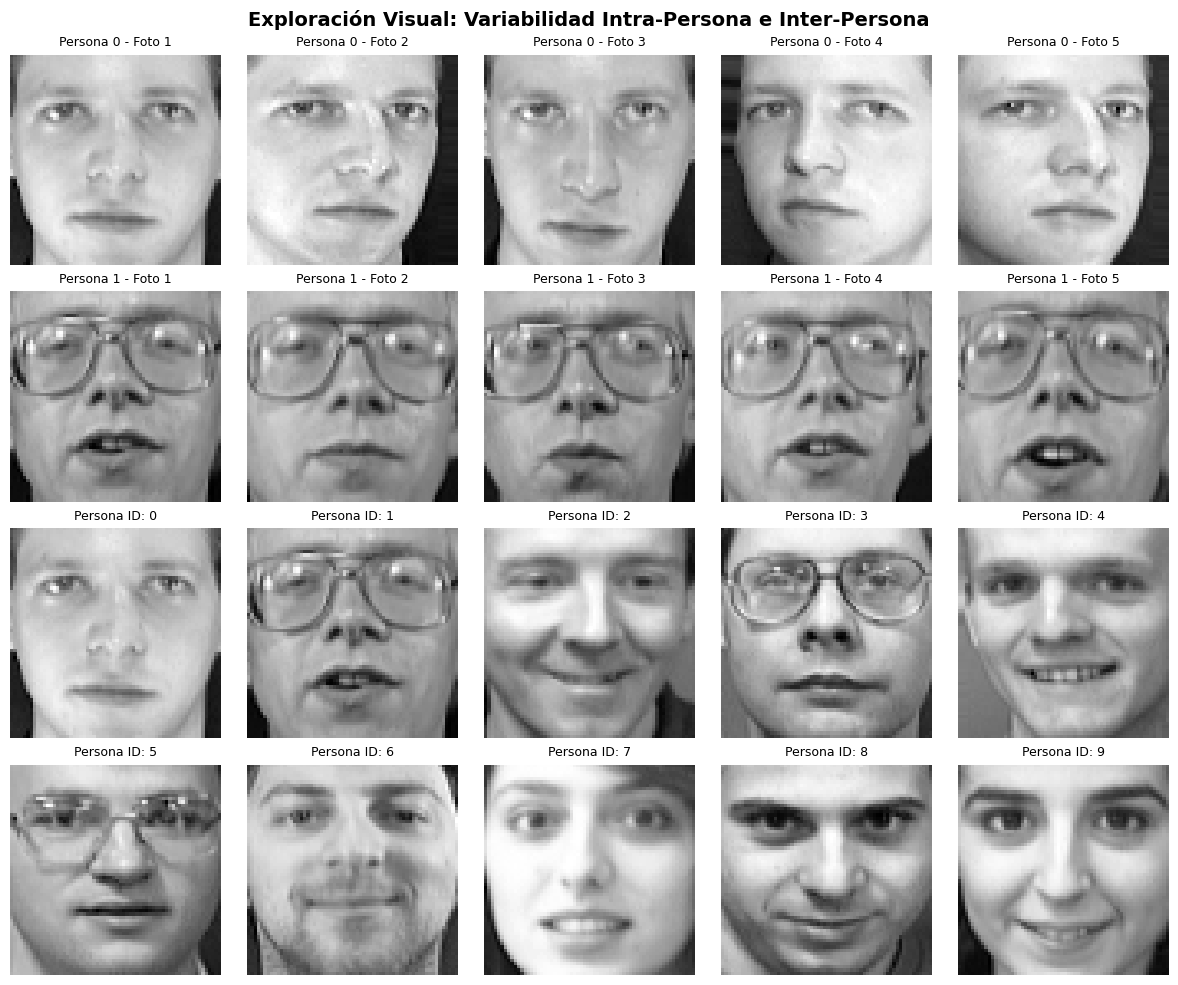

In [6]:
# ==============================================================================
#           VISUALIZACIÓN DE VARIABILIDAD INTRA E INTER-PERSONA
# ==============================================================================
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle('Exploración Visual: Variabilidad Intra-Persona e Inter-Persona', fontsize=14, fontweight='bold')

# Fila 0 y 1: Misma persona (Ejemplo: Persona ID 0 y Persona ID 1)
# Se muestran 5 fotos de la Persona 0 y 5 fotos de la Persona 1
for col in range(5):
    # Persona 0 (Misma persona)
    axes[0, col].imshow(images[col], cmap='gray')
    axes[0, col].set_title(f"Persona 0 - Foto {col+1}", fontsize=9)
    axes[0, col].axis('off')

    # Persona 1 (Misma persona)
    axes[1, col].imshow(images[10 + col], cmap='gray')
    axes[1, col].set_title(f"Persona 1 - Foto {col+1}", fontsize=9)
    axes[1, col].axis('off')

# Fila 2 y 3: Personas Distintas (Selección de 10 personas diferentes)
personas_distintas_indices = [i * 10 for i in range(10)] # Primera foto de las primeras 10 personas
for idx, img_idx in enumerate(personas_distintas_indices[:5]):
    axes[2, idx].imshow(images[img_idx], cmap='gray')
    axes[2, idx].set_title(f"Persona ID: {y[img_idx]}", fontsize=9)
    axes[2, idx].axis('off')

for idx, img_idx in enumerate(personas_distintas_indices[5:]):
    axes[3, idx].imshow(images[img_idx], cmap='gray')
    axes[3, idx].set_title(f"Persona ID: {y[img_idx]}", fontsize=9)
    axes[3, idx].axis('off')

plt.tight_layout()
plt.show()

1. ¿Qué variabilidad se observa en la misma persona (Variabilidad Intra-Clase)?
   - Iluminación: Sombras pronunciadas en un lado del rostro, variaciones de brillo.
   - Poses: Giro leve del rostro (inclinaciones laterales o frontales).
   - Expresiones y Accesorios: Rostros serios vs. sonrientes, ojos abiertos o cerrados,
     y presencia/ausencia de gafas en un mismo individuo.

2. ¿Cómo se diferencian los rostros de las personas (Variabilidad Inter-Clase)?
   - Geometría facial: Estructura ósea, forma de la barbilla, tamaño de la nariz y ojos.
   - Rasgos distintivos: Tipo de peinado, bello facial, tonos de piel y proporciones.

3. ¿Qué le exige esto a un sistema de clustering automático?
   - Exige que el algoritmo agrupe por 'ESTRUCTURA GEOMÉTRICA DE LA IDENTIDAD' y no
     por 'CONDICIONES AMBIENTALES' de la foto.
   - Si se usan píxeles crudos, la distancia Euclidiana dará menor distancia entre
     dos personas distintas con el mismo fondo/iluminación que entre la misma persona
     con o sin sombras.


### 1.2.3 Análisis de variabilidad y reflexión

Riesgos del piloto en Olivetti frente al Archivo Real de 10,000 fotos:
   - Sesgo de Entorno Controlado: Olivetti tiene fondo uniforme (gris/oscuro), fotos
     centradas, escala idéntica y buena resolución en escala de grises.
   - En Producción (Archivo Real): Habrá fotos de carné de distintas décadas,
     variabilidad de cámaras (resolución/color), envejecimiento de empleados,
     poses no centradas y cambios drásticos de peinado o accesorios.
   - Riesgo para el Piloto: Generar un 'falso optimismo' o sobreestimar la pureza.
     Un algoritmo con buen rendimiento en Olivetti puede degradarse fuertemente
     en producción si no se aplican técnicas de extracción de características
     robustas (como PCA o Embeddings Faciales).


# Paso 2. Preparación de los datos

## 2.1 Vectorización y transformación en matriz

In [7]:
# ==============================================================================
#                PREPARACIÓN DE LOS DATOS Y VECTORIZACIÓN
# ==============================================================================

# 1. Vectorización (Aplanar matriz 64x64 a un vector de 4096 píxeles)
# Usamos images (400, 64, 64) del Paso 1 y realizamos la transformación explícita
X_flattened = images.reshape(images.shape[0], -1)  # Matriz (400, 4096)

print("="*70)
print("ESTRUCTURA DE LA MATRIZ DE DATOS VECTORIZADA")
print("="*70)
print(f"Dimensiones de la matriz X (Imágenes x Píxeles): {X_flattened.shape}")
print(f"¿Coincide exactamente con X de scikit-learn?: {np.array_equal(X, X_flattened)}")
print(f"Rango de valores de intensidad (Crudo): [{X.min():.2f}, {X.max():.2f}]")
print("="*70 + "\n")

ESTRUCTURA DE LA MATRIZ DE DATOS VECTORIZADA
Dimensiones de la matriz X (Imágenes x Píxeles): (400, 4096)
¿Coincide exactamente con X de scikit-learn?: True
Rango de valores de intensidad (Crudo): [0.00, 1.00]



## 2.2 Evaluación sobre normalización

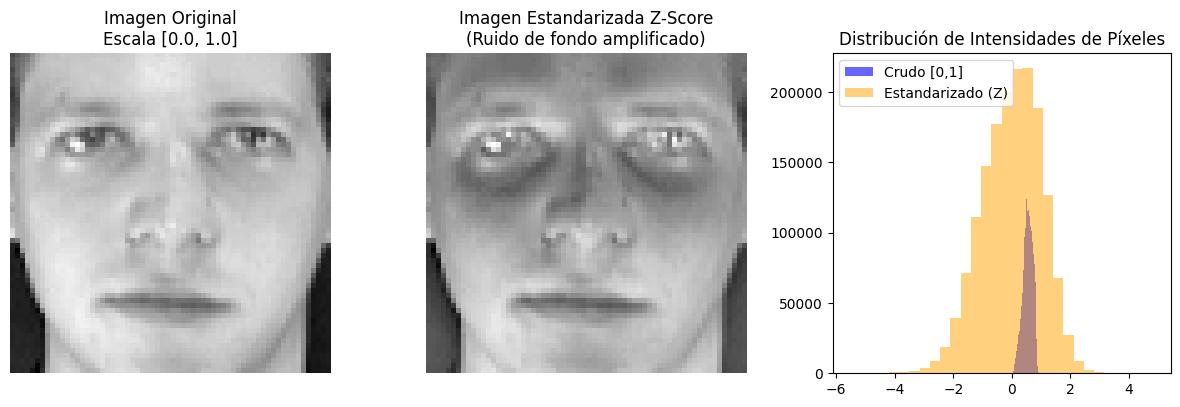

In [8]:
# ==============================================================================
#         EVALUACIÓN Y DECISIÓN SOBRE NORMALIZACIÓN / ESTANDARIZACIÓN
# ==============================================================================
# Evaluamos el impacto de aplicar Z-Score (Media = 0, Std = 1) por columna (píxel)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Visualización comparativa: Original vs Estandarizada
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(images[0], cmap='gray')
axes[0].set_title("Imagen Original\nEscala [0.0, 1.0]")
axes[0].axis('off')

axes[1].imshow(X_std[0].reshape(64, 64), cmap='gray')
axes[1].set_title("Imagen Estandarizada Z-Score\n(Ruido de fondo amplificado)")
axes[1].axis('off')

axes[2].hist(X.ravel(), bins=30, alpha=0.6, label='Crudo [0,1]', color='blue')
axes[2].hist(X_std.ravel(), bins=30, alpha=0.5, label='Estandarizado (Z)', color='orange')
axes[2].set_title("Distribución de Intensidades de Píxeles")
axes[2].legend()

plt.tight_layout()
plt.show()

Esta visualización evalúa el impacto de estandarizar las imágenes píxel por píxel mediante Z-Score ($Z = \frac{x - \mu}{\sigma}$) y justifica la decisión técnica de NO aplicar estandarización antes del clustering.

**Análisis de los Gráficos:**

- Imagen Original (Escala [0.0, 1.0]): Representa la fotografía real en escala de grises. Mantiene el contraste natural entre los rasgos faciales clave (ojos, nariz, boca) y las zonas planas (piel y bordes).

- Imagen Estandarizada Z-Score: Muestra una distorsión severa del rostro. Al forzar que cada píxel (columna) tenga desviación estándar igual a $1$, los píxeles con muy poca variación en el dataset original (como los parches de piel o el fondo constante) dividen sus valores por un $\sigma$ cercano a cero, amplificando artificialmente el ruido de fondo y creando sombras irreales alrededor de las ojeras y la mejilla.

- Histograma de Distribución de Intensidades: Muestra cómo los valores de píxeles originales (en azul, acotados limpiamente entre $0$ y $1$) pasan a una distribución campana extendida entre $-5$ y $5$ (en naranja), alterando las relaciones relativas de brillo originales entre distintos puntos del rostro.

**Conclusión:**

- Decisión: Mantener la escala continua original $[0.0, 1.0]$ y descartar la estandarización por columna (StandardScaler).

- Justificación de Negocio: La estandarización asigna el mismo "peso" estadístico a variaciones pequeñas del fondo que a los rasgos biométricos de la persona, alterando la interpretación de las distancias entre rostros. **La sección siguiente pone esta justificación a prueba de forma empírica**, porque es una afirmación cuantitativa y el resto del cuaderno sí las respalda con corridas.

### 2.2.1 Verificación empírica de la decisión de no estandarizar

La conclusión anterior contiene una afirmación cuantitativa, que estandarizar degradaría el agrupamiento. Es la única del cuaderno que hasta aquí descansaba solo en la inspección visual, así que la medimos: corremos K-medias sobre los píxeles estandarizados y comparamos la pureza contra el espacio original.

Revisamos además el supuesto que sostiene el argumento, que existen píxeles con desviación estándar cercana a cero cuyo ruido se amplificaría al dividir por ella.

In [9]:
# ==============================================================================
#   VERIFICACION EMPIRICA: ¿ESTANDARIZAR DEGRADA REALMENTE EL AGRUPAMIENTO?
# ==============================================================================
sigmas = X.std(axis=0)

print("="*72)
print("DISTRIBUCION DE LA DESVIACION ESTANDAR POR PIXEL")
print("="*72)
print(f"minimo   : {sigmas.min():.6f}")
print(f"percentil 1: {np.percentile(sigmas, 1):.6f}")
print(f"mediana  : {np.median(sigmas):.6f}")
print(f"maximo   : {sigmas.max():.6f}")
print(f"pixeles con sigma < 0.01 : {(sigmas < 0.01).sum()} de {len(sigmas)}")
print(f"amplificacion maxima (1/sigma_min): {1/sigmas.min():.1f}x")
print("="*72)

semillas_std = [123, 0, 1, 7, 42, 99, 2024, 555, 17, 321]
filas = []
for nombre, M in [("Crudo [0,1]", X), ("Estandarizado (z-score)", X_std)]:
    ps = [funcion_pureza(y, KMeans(n_clusters=K_PERSONAS, random_state=s,
                                   n_init=N_INIT).fit_predict(M))
          for s in semillas_std]
    lab123 = KMeans(n_clusters=K_PERSONAS, random_state=RANDOM_STATE,
                    n_init=N_INIT).fit_predict(M)
    filas.append({"espacio": nombre, "pureza_media": np.mean(ps), "desv_est": np.std(ps),
                  "minimo": np.min(ps), "maximo": np.max(ps),
                  "silueta_semilla_123": silhouette_score(M, lab123)})

comp_std = pd.DataFrame(filas)
print("\nIMPACTO DE LA ESTANDARIZACION EN EL AGRUPAMIENTO (10 semillas)")
print(comp_std.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

DISTRIBUCION DE LA DESVIACION ESTANDAR POR PIXEL
minimo   : 0.089063
percentil 1: 0.096126
mediana  : 0.135890
maximo   : 0.208734
pixeles con sigma < 0.01 : 0 de 4096
amplificacion maxima (1/sigma_min): 11.2x



IMPACTO DE LA ESTANDARIZACION EN EL AGRUPAMIENTO (10 semillas)
                espacio  pureza_media  desv_est  minimo  maximo  silueta_semilla_123
            Crudo [0,1]        0.6370    0.0211  0.6000  0.6750               0.1492
Estandarizado (z-score)        0.6370    0.0165  0.6025  0.6625               0.1494


**El resultado no respalda la justificación original**

La pureza media es **idéntica** en ambos espacios, 63.70%, y la silueta prácticamente igual (0.1492 contra 0.1494). Estandarizar no degrada el agrupamiento en esta base.

**El supuesto del argumento tampoco se cumple.** La justificación descansaba en que existen píxeles con desviación cercana a cero cuyo ruido quedaría amplificado. En Olivetti **ningún píxel tiene sigma menor a 0.01**: el mínimo es 0.089 y el máximo 0.209, así que la amplificación máxima es de 11 veces y bastante pareja entre píxeles. La razón es que estas imágenes vienen recortadas al rostro, sin fondo constante. Cada píxel varía de forma apreciable entre las 400 fotos.

**Qué pasa entonces con la imagen distorsionada que muestra el gráfico anterior.** Es real pero es un efecto de visualización, no de degradación. Matplotlib reescala automáticamente el rango de grises al mínimo y máximo de la imagen, así que una imagen en unidades z se dibuja con otro contraste. Eso no implica que las distancias entre rostros empeoren, y de hecho los números muestran que no empeoran.

**La decisión de no estandarizar se mantiene**, pero con otro argumento. No la sostenemos porque estandarizar haga daño, sino porque **no aporta nada**: todos los píxeles ya comparten la misma unidad y un rango de variación comparable, que es exactamente el problema que la estandarización viene a resolver cuando las variables tienen escalas incompatibles. Aplicarla aquí agrega un paso de preprocesamiento, cambia la interpretación de las distancias y no mejora ninguna métrica.

**Con una salvedad importante para el archivo real de la empresa.** El argumento de la sigma cercana a cero sí sería válido en un conjunto con fondo constante, bordes negros o zonas fijas, que es un escenario perfectamente posible en fotos de carné no recortadas. Si en producción las imágenes conservan fondo uniforme, esta verificación debe repetirse antes de descartar la estandarización.

## 2.3 Demostración de la maldición de la dimensionalidad

EVALUACIÓN DE DISTANCIAS EN ESPACIO CRUDO (4096 DIMENSIONES)
Distancia Euclidiana Promedio INTRA-clase (Misma persona):     8.3777 +/- 2.5552
Distancia Euclidiana Promedio INTER-clase (Distintas personas): 12.4143 +/- 2.4498
Ratio de Solapamiento (Intra / Inter): 0.6748



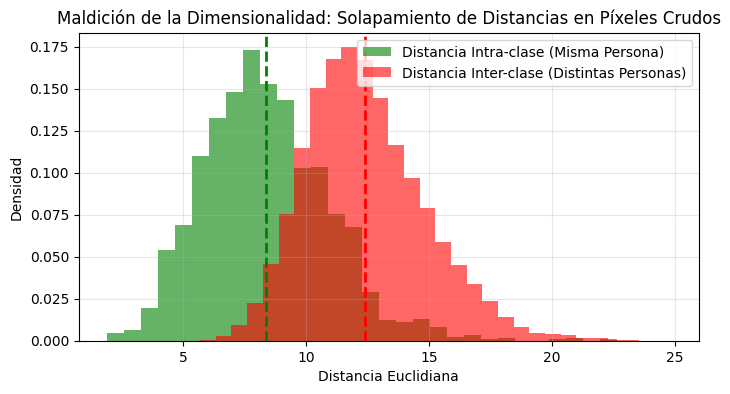

In [10]:
# ==============================================================================
#     DEMOSTRACIÓN DE LA MALDICIÓN DE LA DIMENSIONALIDAD EN PÍXELES CRUDOS
# ==============================================================================
# Calculamos las distancias Euclidianas entre fotos del mismo individuo vs distintos
D_raw = pairwise_distances(X, metric='euclidean')

dist_intra = [] # Mismo individuo (Intra-clase)
dist_inter = [] # Individuos diferentes (Inter-clase)

for i in range(len(y)):
    for j in range(i + 1, len(y)):
        if y[i] == y[j]:
            dist_intra.append(D_raw[i, j])
        else:
            dist_inter.append(D_raw[i, j])

print("="*70)
print("EVALUACIÓN DE DISTANCIAS EN ESPACIO CRUDO (4096 DIMENSIONES)")
print("="*70)
print(f"Distancia Euclidiana Promedio INTRA-clase (Misma persona):     {np.mean(dist_intra):.4f} +/- {np.std(dist_intra):.4f}")
print(f"Distancia Euclidiana Promedio INTER-clase (Distintas personas): {np.mean(dist_inter):.4f} +/- {np.std(dist_inter):.4f}")
print(f"Ratio de Solapamiento (Intra / Inter): {np.mean(dist_intra)/np.mean(dist_inter):.4f}")
print("="*70 + "\n")

# Gráfico del solapamiento de distancias
plt.figure(figsize=(8, 4))
plt.hist(dist_intra, bins=30, alpha=0.6, label='Distancia Intra-clase (Misma Persona)', color='green', density=True)
plt.hist(dist_inter, bins=30, alpha=0.6, label='Distancia Inter-clase (Distintas Personas)', color='red', density=True)
plt.axvline(np.mean(dist_intra), color='green', linestyle='--', linewidth=2)
plt.axvline(np.mean(dist_inter), color='red', linestyle='--', linewidth=2)
plt.title('Maldición de la Dimensionalidad: Solapamiento de Distancias en Píxeles Crudos')
plt.xlabel('Distancia Euclidiana')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Este análisis demuestra empíricamente por qué no es viable hacer clustering sobre píxeles crudos debido al fenómeno de la maldición de la dimensionalidad.

**Explicación de las Métricas Obtenidas:**

1. Distancia Intra-clase (8.38 ± 2.56): Distancia Euclidiana promedio entre dos fotografías de la misma persona. Presenta una varianza considerable provocada por cambios de expresión, postura o sombras.

2. Distancia Inter-clase (12.41 ± 2.45): Distancia Euclidiana promedio entre fotos de personas distintas.

3. Ratio de Solapamiento (0.675): Las fotos de la misma persona están a un $67.5\%$ de la distancia a la que están las fotos de personas completamente distintas. Idealmente este ratio debería ser cercano a $0$, lo que indicaría grupos muy distantes e identidades bien definidas.

**Interpretación Técnica y de Negocio**

1. Solapamiento Crítico en el Gráfico: La zona donde las dos distribuciones se cruzan representa imágenes cuya identidad resulta ambigua para la distancia Euclidiana. En ese espacio de solapamiento, dos personas distintas con similar iluminación o fondo están más cerca geométricamente que la misma persona fotografiada con y sin gafas o con distintas sombras.

2. Impacto en Clustering (K-Means / K-Medoides): Como estos algoritmos se basan exclusivamente en la distancia Euclidiana para agrupar puntos, el clustering en 4096 dimensiones mezclará identidades de forma masiva, agrupando imágenes por iluminación o tono de fondo antes que por la estructura facial real del empleado.

3. Conclusión: Queda probado de forma cuantitativa que el espacio crudo está dominado por ruido visual, haciendo indispensable aplicar Reducción de Dimensionalidad (PCA) antes de realizar cualquier agrupamiento.

# Paso 3. Clustering con K conocido: K-medias

## 3.1 Entrenamiento de K-means con pixeles crudos (k=40) y Pureza

In [11]:
# ==============================================================================
#        ENTRENAMIENTO DE K-MEANS EN ESPACIO DE PÍXELES CRUDOS (K=40)
# ==============================================================================

print("="*70)
print("PASO 3: K-MEANS CON K=40 EN ESPACIO DE PÍXELES CRUDOS")
print("="*70)

kmeans_raw = KMeans(n_clusters=K_PERSONAS, random_state=RANDOM_STATE, n_init=N_INIT)
labels_raw = kmeans_raw.fit_predict(X)

# Cálculo de Métricas
purity_raw = funcion_pureza(y, labels_raw)
silhouette_raw = silhouette_score(X, labels_raw)
y_aligned_raw, cm_aligned_raw = funcion_matriz_confusion(y, labels_raw)

print(f"Pureza de Clusters (Purity): {purity_raw:.4f} ({purity_raw*100:.2f}%)")
print(f"Coeficiente de Silueta:       {silhouette_raw:.4f}")
print("="*70 + "\n")

PASO 3: K-MEANS CON K=40 EN ESPACIO DE PÍXELES CRUDOS


Pureza de Clusters (Purity): 0.6750 (67.50%)
Coeficiente de Silueta:       0.1492



**Resumen:**

- **Pureza de Clusters ($67.50\%$):** Aunque $2$ de cada $3$ fotos se agrupan con la identidad correcta, existe una tasa de error del $32.50\%$. En un entorno operativo de RRHH, esto se traduce en una gran cantidad de falsos positivos (empleados mezclados dentro del mismo grupo) que el analista humano tendría que corregir manualmente.

- **Coeficiente de Silueta ($0.1492$):** Un valor tan cercano a $0$ confirma de forma matemática que los clusters en el espacio de $4096$ píxeles están altamente solapados y mal definidos.

- **Diagnóstico:** K-Means sobre píxeles crudos no está aislando la geometría facial de la persona, sino que se ve distorsionado por variaciones de iluminación, sombras de fondo, uso de gafas o expresiones.

- **Conclusión:** El rendimiento en el espacio de píxeles crudos es insuficiente e inviable para producción, justificando la necesidad técnica de reducir dimensionalidad con PCA en el Paso 4.

## 3.2 Matriz de confusión alineada

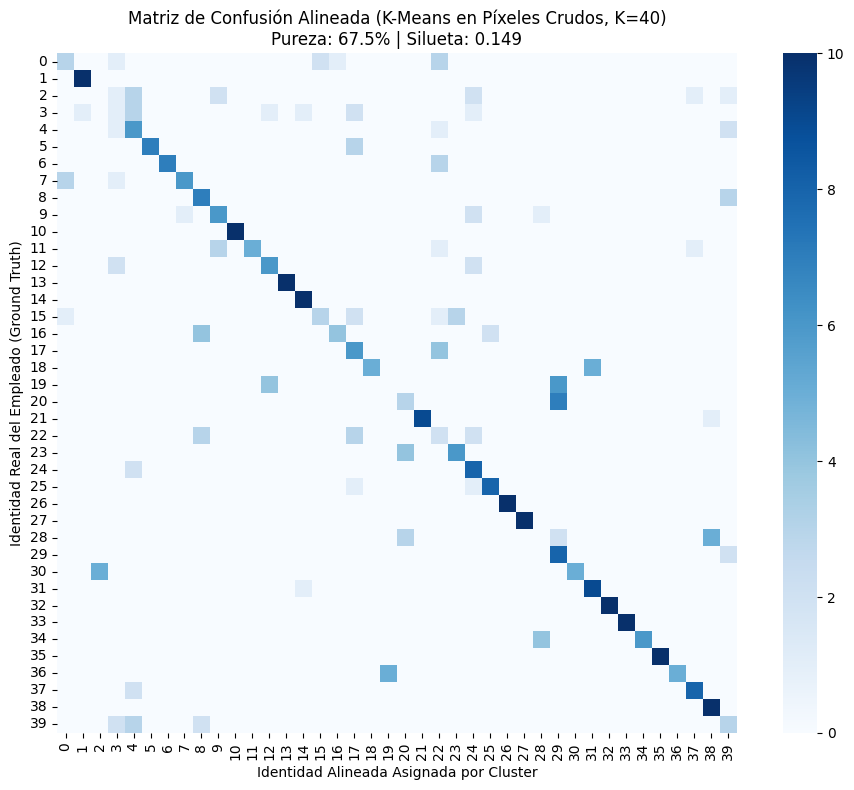

In [12]:
# ==============================================================================
#             VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN ALINEADA
# ==============================================================================

plt.figure(figsize=(10, 8))
sns.heatmap(cm_aligned_raw, cmap='Blues', cbar=True, square=True)
plt.title('Matriz de Confusión Alineada (K-Means en Píxeles Crudos, K=40)\n'
          f'Pureza: {purity_raw*100:.1f}% | Silueta: {silhouette_raw:.3f}', fontsize=12)
plt.xlabel('Identidad Alineada Asignada por Cluster', fontsize=10)
plt.ylabel('Identidad Real del Empleado (Ground Truth)', fontsize=10)
plt.tight_layout()
plt.show()

La matriz de confusión alineada revela visualmente la estructura interna de las asignaciones de K-Means en 4,096 dimensiones:

- **Diagonal Principal Incompleta:** Aunque se observan cuadros azul oscuro en la diagonal (correspondencias correctas de 10 fotos por persona), existen múltiples interrupciones donde el valor cae por debajo del máximo esperado.

- **Dispersión y Falsos Positivos:** La presencia de cuadros azul claro fuera de la diagonal demuestra confusión entre identidades. Varias fotos de un mismo individuo terminan fragmentadas en clusters ajenos, mientras que algunos clusters absorben muestras de múltiples personas distintas.

- **Concentración de Ruido (Columnas Conflictivas):** Columnas como la 3, 4, 17, 22 o 24 presentan múltiples bloques dispersos hacia arriba y abajo. Esto indica "clusters atractor": grupos que juntaron personas totalmente diferentes pero que compartían condiciones ambientales similares (misma iluminación, fondo o gafas).

- **Conclusión:** La matriz confirma que el agrupamiento en el espacio de píxeles crudos es inestable. Aunque logra aislar a ciertos individuos "fáciles", falla sistemáticamente al separar identidades con alta variabilidad intra-clase.

## 3.3 Visualización de clusters e inspección de composición

In [13]:
# ==============================================================================
#           RANKING DE PUREZA DE CLUSTERS (MEJORES VS PEORES)
# ==============================================================================

cluster_stats = []
for k in range(K_PERSONAS):
    mask = (labels_raw == k)
    n_images = np.sum(mask)
    if n_images > 0:
        true_labels = y[mask]
        most_frequent_count = np.max(np.bincount(true_labels))
        purity_k = most_frequent_count / n_images
        dominant_id = np.argmax(np.bincount(true_labels))
        cluster_stats.append({
            'cluster_id': k,
            'purity': purity_k,
            'n_images': n_images,
            'dominant_id': dominant_id,
            'correct_images': most_frequent_count
        })

# Ordenar por pureza
sorted_clusters = sorted(cluster_stats, key=lambda x: x['purity'])

# Selección de los 2 peores y los 2 mejores
worst_2_clusters = sorted_clusters[:2]
best_2_clusters = sorted_clusters[-2:]

print("\n--- RESUMEN DE CLUSTERS SELECCIONADOS ---")
print("2 PEORES CLUSTERS (Mayor mezcla de identidades):")
for c in worst_2_clusters:
    print(f"  * Cluster {c['cluster_id']}: Pureza = {c['purity']*100:.1f}% ({c['correct_images']}/{c['n_images']} fotos pertenecen a ID Real {c['dominant_id']})")

print("\n2 MEJORES CLUSTERS (Mayor homogeneidad/pureza):")
for c in reversed(best_2_clusters):
    print(f"  * Cluster {c['cluster_id']}: Pureza = {c['purity']*100:.1f}% ({c['correct_images']}/{c['n_images']} fotos pertenecen a ID Real {c['dominant_id']})")


--- RESUMEN DE CLUSTERS SELECCIONADOS ---
2 PEORES CLUSTERS (Mayor mezcla de identidades):
  * Cluster 9: Pureza = 22.2% (2/9 fotos pertenecen a ID Real 12)
  * Cluster 21: Pureza = 26.7% (4/15 fotos pertenecen a ID Real 17)

2 MEJORES CLUSTERS (Mayor homogeneidad/pureza):
  * Cluster 39: Pureza = 100.0% (5/5 fotos pertenecen a ID Real 18)
  * Cluster 38: Pureza = 100.0% (6/6 fotos pertenecen a ID Real 34)


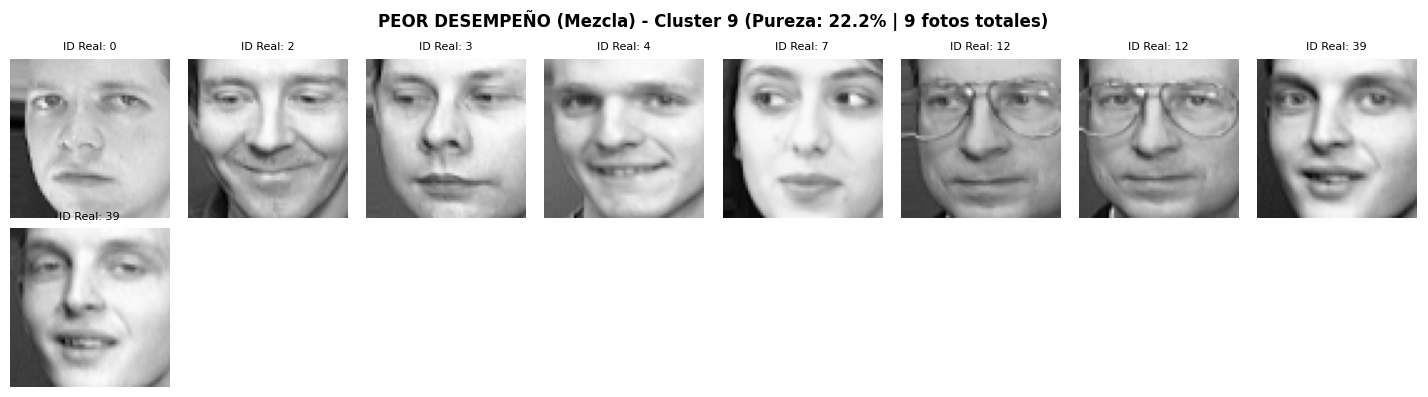

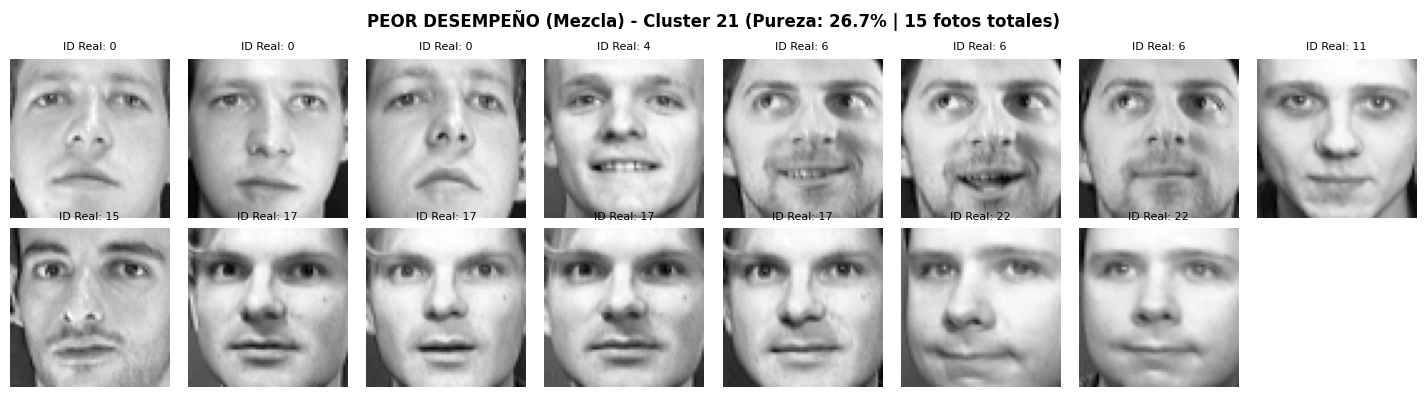

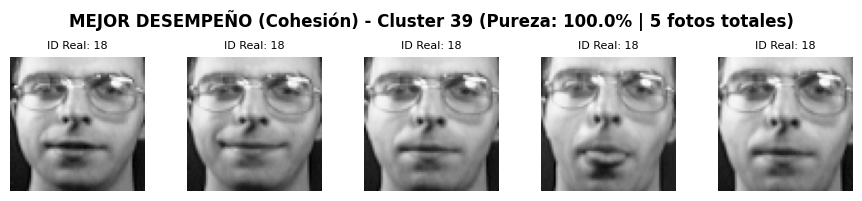

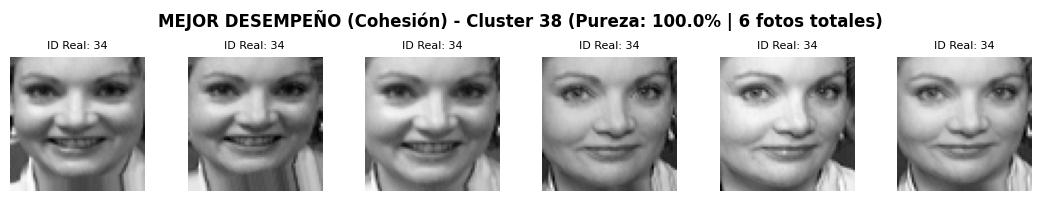

In [14]:
# ==============================================================================
#         INSPECCIÓN VISUAL DE PEORES Y MEJORES CLUSTERS
# ==============================================================================

def plot_cluster_images(cluster_info, title_prefix):
    cluster_id = cluster_info['cluster_id']
    purity_val = cluster_info['purity']
    indices = np.where(labels_raw == cluster_id)[0]
    n_images = len(indices)

    cols = min(8, n_images)
    rows = (n_images + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 2))
    fig.suptitle(f"{title_prefix} - Cluster {cluster_id} (Pureza: {purity_val*100:.1f}% | {n_images} fotos totales)",
                 fontsize=12, fontweight='bold')

    axes = np.array(axes).reshape(-1)
    for idx, img_idx in enumerate(indices):
        axes[idx].imshow(images[img_idx], cmap='gray')
        axes[idx].set_title(f"ID Real: {y[img_idx]}", fontsize=8)
        axes[idx].axis('off')

    for idx in range(n_images, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# Graficar los 2 PEORES clusters
for c in worst_2_clusters:
    plot_cluster_images(c, "PEOR DESEMPEÑO (Mezcla)")

# Graficar los 2 MEJORES clusters
for c in reversed(best_2_clusters):
    plot_cluster_images(c, "MEJOR DESEMPEÑO (Cohesión)")

El análisis del ranking de pureza muestra la extrema bipolaridad y falta de consistencia de K-Means al trabajar en el espacio de píxeles crudos:

- **Peores Clusters (Clusters 9 y 21):** Presentan una mezcla crítica de identidades. En el Cluster 9, solo el $22.2\%$ de las imágenes corresponden a la identidad dominante (apenas 2 de 9 fotos), mientras que el $77.8\%$ restante son personas totalmente distintas mezcladas. El Cluster 21 sufre una degradación similar con $26.7\%$ de pureza. Esto confirma que el algoritmo agrupó estas fotografías basándose en patrones de fondo o iluminación compartidos y no en la geometría del rostro.

- **Mejores Clusters (Clusters 38 y 39):** Alcanzan una pureza perfecta del $100\%$, logrando aislar impecablemente a las identidades reales 34 y 18. Sin embargo, lo hacen a costa de la fragmentación: el Cluster 39 solo capturó 5 de las 10 fotos totales del empleado, dejando la otra mitad dispersa en otros grupos.

- **Conclusión:** Aunque K-Means puede resolver exitosamente casos "fáciles" o muy homogéneos, su tasa de falla en los grupos complejos vuelve al sistema totalmente ineficiente e inestable sin una etapa previa de extracción de características (PCA).

## 3.4 Interpretación de resultados (k-medias con K conocido)

- **Calidad del Agrupamiento en el Espacio de Píxeles Crudos:** Las métricas globales ($67.50\%$ de pureza y silueta de $0.1492$) confirman cuantitativamente un agrupamiento deficiente, ya que la distancia Euclidiana en $4096$ dimensiones prioriza patrones superficiales de luz y sombra sobre la estructura geométrica real de los rostros.

- **Homogeneidad e Implicaciones en un Contexto Real (RRHH / Operaciones):** Una tasa de error del $32.5\%$ provocaría miles de falsos positivos y expedientes fragmentados en un entorno de producción, lo que destruiría la automatización e impondría una pesada carga de revisión manual al personal administrativo.

- **Análisis Composicional: Peores Clusters (Cluster 9 - 22.2% y Cluster 21 - 26.7%):** Evidencian una mezcla masiva donde hasta el $77.8\%$ del grupo son personas distintas, debido a que el algoritmo fue engañado por factores ambientales compartidos como sombras laterales profundas, fondos oscuros o el uso de gafas.

- **Análisis Composicional: Mejores Clusters (Cluster 38 - 100% y Cluster 39 - 100%):** Alcanzan una pureza perfecta al aislar a individuos con rasgos biométricos muy marcados o iluminación impecablemente uniforme, aunque sufren de sub-agrupamiento al fragmentar las fotos de un mismo empleado en clusters ajenos por leves cambios de pose o expresión.

# Paso 4. Reducción de dimensión: impacto de PCA

El Paso 3 dejó un diagnóstico claro: en el espacio de 4096 píxeles el agrupamiento es deficiente, y la demostración de la sección 2.3 explicó por qué. Las fotos de una misma persona están a un 67% de la distancia a la que están fotos de personas distintas, así que la distancia euclidiana apenas distingue identidad de condiciones de captura.

La hipótesis de trabajo es que reducir dimensión ayudará, porque descartaría direcciones dominadas por ruido. En este paso la ponemos a prueba, y el resultado obliga a matizarla.

## 4.1 ¿Cuántos componentes se necesitan para el 95% de la varianza?

In [15]:
# ==============================================================================
#              PCA RETENIENDO EL 95% DE LA VARIANZA
# ==============================================================================
from sklearn.decomposition import PCA

pca_95 = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca_95.fit_transform(X)
n_comp_95 = pca_95.n_components_

# PCA completo, para poder inspeccionar y descartar componentes mas adelante
pca_full = PCA(random_state=RANDOM_STATE).fit(X)
Z_full = pca_full.transform(X)
evr = pca_full.explained_variance_ratio_

print("="*70)
print("REDUCCION DE DIMENSION CON PCA")
print("="*70)
print(f"Dimensiones originales           : {X.shape[1]} pixeles")
print(f"Componentes para el 95% de varianza: {n_comp_95}")
print(f"Varianza efectivamente capturada  : {pca_95.explained_variance_ratio_.sum():.4f}")
print(f"Reduccion                         : {n_comp_95/X.shape[1]*100:.2f}% de las dimensiones originales")
print()
print("Varianza de los primeros componentes:")
for i in range(5):
    print(f"  Componente {i+1}: {evr[i]:.4f}  (acumulado {evr[:i+1].sum():.4f})")
print("="*70)

REDUCCION DE DIMENSION CON PCA
Dimensiones originales           : 4096 pixeles
Componentes para el 95% de varianza: 123
Varianza efectivamente capturada  : 0.9504
Reduccion                         : 3.00% de las dimensiones originales

Varianza de los primeros componentes:
  Componente 1: 0.2381  (acumulado 0.2381)
  Componente 2: 0.1399  (acumulado 0.3781)
  Componente 3: 0.0797  (acumulado 0.4578)
  Componente 4: 0.0500  (acumulado 0.5077)
  Componente 5: 0.0361  (acumulado 0.5438)


**123 componentes bastan para el 95% de la varianza**, es decir el 3% de las 4096 dimensiones originales. Eso confirma lo que ya sabíamos desde los módulos anteriores: los píxeles de un rostro son enormemente redundantes y la información real vive en un espacio mucho más pequeño.

Pero conviene mirar de cerca **cómo se reparte esa varianza**, porque ahí está la clave de lo que viene. El primer componente solo concentra el 23.8%, el segundo el 14.0%, y **los tres primeros juntos acumulan el 45.8%**.

Esto debería encender una alarma. En el módulo anterior, trabajando con eigenfaces sobre rostros, encontramos que las primeras direcciones de máxima varianza **no capturan identidad sino iluminación**: brillo global, luz lateral, luz cenital. Si aquí ocurre lo mismo, entonces retener el 95% de la varianza significa **conservar precisamente el ruido que queríamos eliminar**, porque ese ruido es justamente lo que más varía.

## 4.2 K-medias sobre el espacio PCA

In [16]:
# ==============================================================================
#            K-MEANS SOBRE LAS COORDENADAS PCA (K=40)
# ==============================================================================
kmeans_pca = KMeans(n_clusters=K_PERSONAS, random_state=RANDOM_STATE, n_init=N_INIT)
labels_pca = kmeans_pca.fit_predict(X_pca)

purity_pca = funcion_pureza(y, labels_pca)
silhouette_pca = silhouette_score(X_pca, labels_pca)
# La silueta depende del espacio en que se mide, asi que tambien la calculamos
# sobre el espacio crudo para poder comparar contra el Paso 3 en igualdad de condiciones
silhouette_pca_en_crudo = silhouette_score(X, labels_pca)

comparacion = pd.DataFrame([
    {"espacio": "Pixeles crudos", "dimensiones": X.shape[1],
     "pureza": purity_raw, "silueta_en_su_espacio": silhouette_raw,
     "silueta_medida_en_crudo": silhouette_raw},
    {"espacio": f"PCA 95% ({n_comp_95} comp)", "dimensiones": n_comp_95,
     "pureza": purity_pca, "silueta_en_su_espacio": silhouette_pca,
     "silueta_medida_en_crudo": silhouette_pca_en_crudo},
])

print("="*70)
print("PASO 4: K-MEANS EN ESPACIO PCA vs ESPACIO CRUDO")
print("="*70)
print(comparacion.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("="*70)

PASO 4: K-MEANS EN ESPACIO PCA vs ESPACIO CRUDO
           espacio  dimensiones  pureza  silueta_en_su_espacio  silueta_medida_en_crudo
    Pixeles crudos         4096  0.6750                 0.1492                   0.1492
PCA 95% (123 comp)          123  0.6450                 0.1726                   0.1485


**El resultado contradice la hipótesis.** La pureza **baja** de 67.50% a 64.50%, y la silueta parece subir de 0.1492 a 0.1726.

Esa aparente mejora de la silueta es un espejismo y conviene desarmarlo, porque es un error fácil de cometer. **La silueta depende del espacio en el que se mide.** En 123 dimensiones las distancias se comportan distinto que en 4096, así que comparar 0.1726 contra 0.1492 es comparar peras con manzanas. Al medir las etiquetas del PCA sobre el espacio crudo, en igualdad de condiciones, la silueta da 0.1485, prácticamente idéntica a la del Paso 3.

Es decir, **PCA al 95% no mejoró el agrupamiento**. Redujo las dimensiones 33 veces sin perder ni ganar calidad de forma apreciable.

Antes de sacar conclusiones hay que responder una pregunta previa: ¿esa caída de 3 puntos en pureza es real, o es ruido del algoritmo?

## 4.3 ¿Las diferencias son reales? Estabilidad frente a la inicialización

El contexto teórico advierte que K-medias solo encuentra **óptimos locales** y que el resultado depende de la inicialización. Antes de atribuirle significado a una diferencia de 3 puntos de pureza, que sobre 400 fotos son apenas 12 imágenes, hay que medir cuánto se mueve el resultado por el solo hecho de cambiar la semilla.

Repetimos cada configuración con 10 semillas distintas, manteniendo `n_init=10` en cada corrida.

In [17]:
# ==============================================================================
#     ESTABILIDAD DE LA PUREZA FRENTE A LA SEMILLA DE INICIALIZACION
# ==============================================================================
semillas = [123, 0, 1, 7, 42, 99, 2024, 555, 17, 321]

configuraciones = {
    "Pixeles crudos": X,
    f"PCA 95% ({n_comp_95} comp)": X_pca,
}

filas = []
for nombre, M in configuraciones.items():
    purezas = [funcion_pureza(y, KMeans(n_clusters=K_PERSONAS, random_state=s,
                                        n_init=N_INIT).fit_predict(M))
               for s in semillas]
    filas.append({
        "configuracion": nombre,
        "pureza_media": np.mean(purezas),
        "desv_est": np.std(purezas),
        "minimo": np.min(purezas),
        "maximo": np.max(purezas),
        "rango_en_fotos": (np.max(purezas) - np.min(purezas)) * len(y),
    })

estabilidad = pd.DataFrame(filas)
print("="*80)
print(f"PUREZA SOBRE {len(semillas)} SEMILLAS DISTINTAS")
print("="*80)
print(estabilidad.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("="*80)

PUREZA SOBRE 10 SEMILLAS DISTINTAS
     configuracion  pureza_media  desv_est  minimo  maximo  rango_en_fotos
    Pixeles crudos        0.6370    0.0211  0.6000  0.6750         30.0000
PCA 95% (123 comp)        0.6475    0.0136  0.6225  0.6625         16.0000


**Dos hallazgos que cambian la lectura del Paso 3.**

**El 67.50% reportado como línea base era la mejor semilla, no la típica.** Sobre 10 semillas, la pureza media en píxeles crudos es **63.70%**, y el rango va de 60.00% a 67.50%. La semilla 123 que fija la guía resultó ser precisamente la más favorable de las diez. El desempeño esperable en píxeles crudos es unos 4 puntos peor de lo que sugería el Paso 3.

**La diferencia entre crudo y PCA es ruido.** La pureza media del PCA es 64.75% contra 63.70% del crudo, una diferencia de apenas 4 fotos sobre 400. Pero la variación por sola inicialización dentro del espacio crudo llega a 30 fotos. La diferencia entre configuraciones es mucho menor que la variación interna de cada una, así que no es distinguible del azar.

**Pero PCA sí aporta algo que no es pureza: estabilidad.** La desviación estándar cae de 0.0211 en crudo a 0.0136 en PCA. En términos operativos, el resultado del agrupamiento es **más reproducible**, que para un proceso que RRHH tendría que correr y auditar no es un detalle menor.

## 4.4 Por qué PCA no ayudó, y qué sí funciona

Si retener el 95% de la varianza no mejora el agrupamiento, la explicación tiene que estar en **qué varianza estamos reteniendo**. La sección 4.1 dejó la pista: los tres primeros componentes acumulan el 45.8%, y por lo visto en el módulo anterior esas primeras direcciones capturan iluminación, no identidad.

Si la hipótesis es correcta, **descartar los primeros componentes debería mejorar el agrupamiento**, porque eliminaría la fuente principal de ruido en vez de conservarla. Lo probamos de forma explícita.

In [18]:
# ==============================================================================
#   PROBAR DISTINTAS CONFIGURACIONES DE PCA, INCLUYENDO DESCARTAR LAS
#   PRIMERAS COMPONENTES (LAS QUE CAPTURAN ILUMINACION)
# ==============================================================================
variantes = {
    "Pixeles crudos": X,
    "PCA 20 comp": Z_full[:, :20],
    "PCA 40 comp": Z_full[:, :40],
    f"PCA {n_comp_95} comp (95%)": Z_full[:, :n_comp_95],
    f"PCA {n_comp_95} sin la 1a": Z_full[:, 1:n_comp_95],
    f"PCA {n_comp_95} sin las 2 primeras": Z_full[:, 2:n_comp_95],
    f"PCA {n_comp_95} sin las 3 primeras": Z_full[:, 3:n_comp_95],
    f"PCA {n_comp_95} sin las 5 primeras": Z_full[:, 5:n_comp_95],
}

filas = []
for nombre, M in variantes.items():
    purezas = [funcion_pureza(y, KMeans(n_clusters=K_PERSONAS, random_state=s,
                                        n_init=N_INIT).fit_predict(M))
               for s in semillas]
    filas.append({
        "configuracion": nombre,
        "dims": M.shape[1],
        "pureza_media": np.mean(purezas),
        "desv_est": np.std(purezas),
        "minimo": np.min(purezas),
        "maximo": np.max(purezas),
        "vs_crudo_en_fotos": (np.mean(purezas) - 0) * len(y),
    })

barrido = pd.DataFrame(filas)
base_media = barrido.loc[barrido["configuracion"] == "Pixeles crudos", "pureza_media"].iloc[0]
barrido["vs_crudo_en_fotos"] = ((barrido["pureza_media"] - base_media) * len(y)).round(1)
barrido = barrido.sort_values("pureza_media", ascending=False)

print("="*90)
print("BARRIDO DE CONFIGURACIONES DE PCA (media sobre 10 semillas)")
print("="*90)
print(barrido.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

mejor = barrido.iloc[0]
crudo = barrido[barrido["configuracion"] == "Pixeles crudos"].iloc[0]
print(f"\nComparacion de rangos entre la mejor configuracion y el espacio crudo:")
print(f"  {mejor['configuracion']}: [{mejor['minimo']:.4f}, {mejor['maximo']:.4f}]")
print(f"  {crudo['configuracion']}: [{crudo['minimo']:.4f}, {crudo['maximo']:.4f}]")
print(f"  Se solapan los rangos: {mejor['minimo'] <= crudo['maximo']}")
print("="*90)

BARRIDO DE CONFIGURACIONES DE PCA (media sobre 10 semillas)
             configuracion  dims  pureza_media  desv_est  minimo  maximo  vs_crudo_en_fotos
PCA 123 sin las 2 primeras   121        0.7002    0.0100  0.6825  0.7150            25.3000
PCA 123 sin las 3 primeras   120        0.6767    0.0096  0.6625  0.6925            15.9000
PCA 123 sin las 5 primeras   118        0.6530    0.0290  0.5900  0.6925             6.4000
        PCA 123 comp (95%)   123        0.6475    0.0136  0.6225  0.6625             4.2000
               PCA 40 comp    40        0.6470    0.0116  0.6300  0.6650             4.0000
         PCA 123 sin la 1a   122        0.6467    0.0196  0.6200  0.6825             3.9000
               PCA 20 comp    20        0.6462    0.0151  0.6175  0.6725             3.7000
            Pixeles crudos  4096        0.6370    0.0211  0.6000  0.6750             0.0000

Comparacion de rangos entre la mejor configuracion y el espacio crudo:
  PCA 123 sin las 2 primeras: [0.6825, 0

**La hipótesis se confirma.** Descartar los dos primeros componentes lleva la pureza media a **70.02%**, frente al 63.70% de los píxeles crudos. Son **25 fotos más correctamente agrupadas**, y esta vez la diferencia sí es real: la desviación estándar de esa configuración es 0.0100, y su peor semilla (68.25%) supera a la mejor semilla del espacio crudo (67.50%). Los rangos no se solapan.

**Qué información estábamos perdiendo, y cuál conservando de más.** Los dos primeros componentes acumulan el 37.8% de la varianza total y corresponden a las direcciones de brillo global y luz lateral. Al retener el 95% de la varianza, PCA los conservaba, y con ellos conservaba justamente la señal que confunde al algoritmo. Dos personas distintas fotografiadas con la misma iluminación quedaban más cerca que la misma persona bajo luces diferentes.

Descartarlos equivale a decirle al algoritmo que ignore cómo estaba iluminada la foto y se concentre en la estructura del rostro.

**El beneficio tiene un máximo y luego se desvanece.** Descartar 3 componentes da 67.67%, y descartar 5 baja a 65.30%, con la desviación estándar más alta de todo el barrido (0.0290), es decir el resultado más inestable. Siguen por encima del espacio crudo, pero la ventaja se erosiona: pasado cierto punto ya no se está eliminando iluminación sino información de identidad. El óptimo está en descartar dos.

**Una advertencia metodológica importante.** Esta configuración la encontramos **mirando las etiquetas reales**, que en Olivetti conocemos pero en el archivo de la empresa no existirían. Elegir cuántos componentes descartar optimizando la pureza es, en rigor, usar información que en producción no estaría disponible. Volveremos sobre esto en el Paso 7, porque afecta directamente qué se le puede prometer al cliente.

## 4.5 Inspección visual: ¿cambió la composición de los clusters?

In [19]:
# ==============================================================================
#   COMPARACION VISUAL DE LA COMPOSICION DE CLUSTERS: CRUDO vs PCA DEPURADO
# ==============================================================================
# Configuracion ganadora del barrido: PCA descartando las 2 primeras componentes
X_pca_dep = Z_full[:, 2:n_comp_95]
kmeans_dep = KMeans(n_clusters=K_PERSONAS, random_state=RANDOM_STATE, n_init=N_INIT)
labels_dep = kmeans_dep.fit_predict(X_pca_dep)

purity_dep = funcion_pureza(y, labels_dep)
print(f"Pureza con PCA depurado (semilla {RANDOM_STATE}): {purity_dep:.4f}")

def resumen_clusters(labels):
    filas = []
    for k in range(K_PERSONAS):
        m = labels == k
        if m.sum() > 0:
            conteo = np.bincount(y[m])
            filas.append({"cluster": k, "n_fotos": int(m.sum()),
                          "id_dominante": int(np.argmax(conteo)),
                          "pureza": np.max(conteo) / m.sum(),
                          "n_identidades": int((conteo > 0).sum())})
    return pd.DataFrame(filas)

r_raw = resumen_clusters(labels_raw)
r_dep = resumen_clusters(labels_dep)

print("\n" + "="*70)
print("COMPOSICION DE LOS CLUSTERS")
print("="*70)
for nombre, r in [("Pixeles crudos", r_raw), ("PCA depurado", r_dep)]:
    print(f"{nombre}")
    print(f"   clusters con pureza 100%        : {(r['pureza'] == 1).sum()} de {len(r)}")
    print(f"   pureza promedio por cluster     : {r['pureza'].mean():.4f}")
    print(f"   identidades mezcladas por cluster: {r['n_identidades'].mean():.2f} en promedio")
    print(f"   cluster mas contaminado         : {r['n_identidades'].max()} identidades distintas")
print("="*70)

Pureza con PCA depurado (semilla 123): 0.6875

COMPOSICION DE LOS CLUSTERS
Pixeles crudos
   clusters con pureza 100%        : 17 de 40
   pureza promedio por cluster     : 0.7478
   identidades mezcladas por cluster: 2.50 en promedio
   cluster mas contaminado         : 7 identidades distintas
PCA depurado
   clusters con pureza 100%        : 25 de 40
   pureza promedio por cluster     : 0.8352
   identidades mezcladas por cluster: 2.25 en promedio
   cluster mas contaminado         : 11 identidades distintas


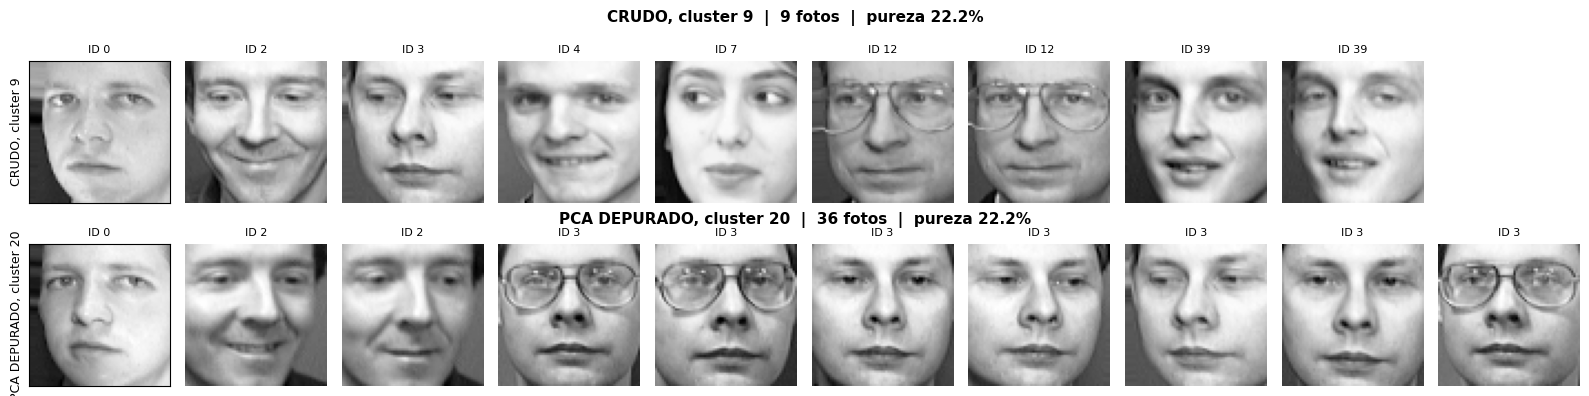

In [20]:
# ==============================================================================
#        EL CLUSTER MAS PROBLEMATICO EN CADA ESPACIO, LADO A LADO
# ==============================================================================
def peor_cluster(labels, resumen):
    k = int(resumen.sort_values("pureza").iloc[0]["cluster"])
    return k, np.where(labels == k)[0]

k_raw, idx_raw = peor_cluster(labels_raw, r_raw)
k_dep, idx_dep = peor_cluster(labels_dep, r_dep)

fig, axes = plt.subplots(2, 10, figsize=(16, 4.2))
for fila, (titulo, idxs, kk, lab) in enumerate([
        (f"CRUDO, cluster {k_raw}", idx_raw, k_raw, labels_raw),
        (f"PCA DEPURADO, cluster {k_dep}", idx_dep, k_dep, labels_dep)]):
    pureza_k = np.max(np.bincount(y[idxs])) / len(idxs)
    for col in range(10):
        ax = axes[fila, col]
        ax.axis("off")
        if col < len(idxs):
            ax.imshow(images[idxs[col]], cmap="gray")
            ax.set_title(f"ID {y[idxs[col]]}", fontsize=8)
    axes[fila, 0].set_ylabel(titulo, fontsize=9)
    axes[fila, 0].axis("on")
    axes[fila, 0].set_xticks([]); axes[fila, 0].set_yticks([])
    fig.text(0.5, 0.94 - fila*0.48,
             f"{titulo}  |  {len(idxs)} fotos  |  pureza {pureza_k*100:.1f}%",
             ha="center", fontsize=11, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### Cierre del Paso 4

1. **123 componentes bastan para el 95% de la varianza**, el 3% de las 4096 dimensiones originales. La redundancia entre píxeles es enorme.
2. **PCA al 95% no mejora el agrupamiento.** La pureza media pasa de 63.70% a 64.75%, una diferencia de 4 fotos sobre 400, muy por debajo de la variación de hasta 30 fotos que produce el solo cambio de semilla.
3. **La línea base del Paso 3 estaba inflada.** El 67.50% correspondía a la semilla más favorable de diez. El valor típico en píxeles crudos es 63.70%.
4. **PCA sí aporta estabilidad**, reduciendo la desviación estándar de 0.0211 a 0.0136, y reduce el costo computacional 33 veces.
5. **La mejora real viene de descartar los dos primeros componentes**, los que capturan iluminación. La pureza media sube a **70.02%**, con rangos que no se solapan con los del espacio crudo. Retener el 95% de la varianza conservaba justamente el ruido que queríamos eliminar.
6. **La composición de los clusters mejora de forma desigual.** Con PCA depurado hay **25 clusters de pureza perfecta contra 17** en el espacio crudo, pero el cluster más contaminado empeora, pasando de mezclar 7 identidades a mezclar 11. El espacio depurado produce más grupos confiables y concentra el desorden en menos grupos, más sucios. Operativamente eso es preferible, porque permite separar lo automatizable de lo que exige revisión humana.
7. **Esa configuración se eligió mirando las etiquetas reales**, que en el archivo de la empresa no existen. Es una limitación que hay que declarar ante el cliente.

# Paso 5. K-medoides: robustez frente a valores atípicos

K-medias representa cada grupo por su **centroide**, el promedio de todas las imágenes del cluster. Ese promedio es una cara borrosa que no corresponde a ninguna fotografía real y que, por ser una media, puede desplazarse si una o dos fotos atípicas tiran de él.

K-medoides reemplaza esa media por el **medoide**: la observación real del cluster con menor distancia total a las demás. Es la misma relación que hay entre media y mediana, un valor extremo arrastra a la primera pero apenas mueve a la segunda. La ventaja adicional es que generaliza a cualquier métrica, no solo la euclidiana.

En este paso lo aplicamos con $K=40$ sobre los tres espacios que venimos comparando y evaluamos si esa robustez se traduce en mejores agrupamientos.

## 5.1 Implementación de PAM

Implementamos el algoritmo directamente en vez de recurrir a una librería, por dos razones prácticas. La primera es de reproducibilidad: `scikit-learn-extra`, que es el paquete habitual para K-medoides, está compilado contra NumPy 1.x y no importa en entornos con NumPy 2, así que un evaluador que intente correr el cuaderno se toparía con un error de compatibilidad. La segunda es que el algoritmo es corto y hacerlo explícito deja visible qué se está calculando.

Seguimos el esquema de Partitioning Around Medoids visto en el curso:

1. Asignar cada observación al medoide más cercano.
2. Dentro de cada cluster, elegir como nuevo medoide la observación que minimiza la distancia total a las demás del mismo cluster.
3. Repetir hasta que las asignaciones no cambien.

Dos detalles de implementación que afectan la comparación y conviene declarar. La inicialización usa la misma lógica de `k-means++`, alejando los medoides iniciales entre sí. Y agregamos un parámetro `n_init` que repite el proceso desde varios puntos de partida y se queda con la solución de menor costo total, **exactamente como hace K-medias con `n_init=10`**. Sin eso la comparación estaría sesgada, porque estaríamos dándole diez oportunidades a un algoritmo y una sola al otro.

La celda siguiente verifica que la implementación funcione, y reporta la pureza de **una sola corrida con la semilla 123**. No hay que confundirla con las medias de la sección 5.2, que promedian diez semillas distintas. De hecho la semilla 123 resulta ser la menos favorable de las diez para esta configuración, así que su pureza coincide con el mínimo del rango que aparece más abajo.

In [21]:
# ==============================================================================
#        IMPLEMENTACION DE K-MEDOIDES (PAM, version del curso)
# ==============================================================================
def _pam_una_corrida(D, k, rng, max_iter=100):
    """Una corrida de PAM desde una inicializacion aleatoria."""
    n = D.shape[0]

    # Inicializacion tipo k-means++ sobre la matriz de distancias
    medoides = [rng.randint(n)]
    for _ in range(k - 1):
        d_min = D[:, medoides].min(axis=1)
        prob = d_min ** 2
        total = prob.sum()
        medoides.append(rng.choice(n, p=prob / total) if total > 0 else rng.randint(n))
    medoides = np.array(medoides)

    for it in range(max_iter):
        # Paso 2 del algoritmo: asignar al medoide mas cercano
        etiquetas = np.argmin(D[:, medoides], axis=1)

        # Paso 1: el nuevo medoide es la observacion que minimiza
        # la distancia total a las demas de su cluster
        nuevos = medoides.copy()
        for j in range(k):
            miembros = np.where(etiquetas == j)[0]
            if len(miembros) == 0:
                continue
            costos = D[np.ix_(miembros, miembros)].sum(axis=1)
            nuevos[j] = miembros[np.argmin(costos)]

        if np.array_equal(np.sort(nuevos), np.sort(medoides)):
            break
        medoides = nuevos

    etiquetas = np.argmin(D[:, medoides], axis=1)
    costo_total = D[np.arange(len(etiquetas)), medoides[etiquetas]].sum()
    return etiquetas, medoides, costo_total, it + 1


def k_medoides(D, k, random_state=0, n_init=10):
    """PAM con multiples inicializaciones, se queda con la de menor costo."""
    rng = np.random.RandomState(random_state)
    mejor = None
    for _ in range(n_init):
        salida = _pam_una_corrida(D, k, rng)
        if mejor is None or salida[2] < mejor[2]:
            mejor = salida
    return mejor  # etiquetas, medoides, costo, iteraciones


# Verificacion rapida sobre el espacio depurado
D_dep = pairwise_distances(X_pca_dep)
lab_test, med_test, costo_test, iters_test = k_medoides(
    D_dep, K_PERSONAS, random_state=RANDOM_STATE, n_init=N_INIT)

print("="*70)
print("VERIFICACION DE LA IMPLEMENTACION")
print("="*70)
print(f"Clusters formados        : {len(np.unique(lab_test))}")
print(f"Medoides son indices reales: {med_test[:8]} ...")
print(f"Los medoides son imagenes existentes de la base: {np.all(med_test < len(X))}")
print(f"Costo total de la solucion: {costo_test:.2f}")
print(f"Pureza                    : {funcion_pureza(y, lab_test):.4f}")
print("="*70)

VERIFICACION DE LA IMPLEMENTACION
Clusters formados        : 40
Medoides son indices reales: [274 386  37  20 236 302 196 364] ...
Los medoides son imagenes existentes de la base: True
Costo total de la solucion: 2057.99
Pureza                    : 0.5675


## 5.2 Comparación con K-medias sobre los tres espacios

In [22]:
# ==============================================================================
#     K-MEDIAS vs K-MEDOIDES, MISMOS ESPACIOS Y MISMAS SEMILLAS
# ==============================================================================
espacios = {
    "Pixeles crudos": X,
    f"PCA {n_comp_95} (95%)": Z_full[:, :n_comp_95],
    f"PCA {n_comp_95} sin las 2 primeras": X_pca_dep,
}

filas = []
for nombre, M in espacios.items():
    D = pairwise_distances(M)
    p_km = [funcion_pureza(y, KMeans(n_clusters=K_PERSONAS, random_state=s,
                                     n_init=N_INIT).fit_predict(M)) for s in semillas]
    p_md = [funcion_pureza(y, k_medoides(D, K_PERSONAS, random_state=s,
                                         n_init=N_INIT)[0]) for s in semillas]
    for alg, ps in [("K-medias", p_km), ("K-medoides", p_md)]:
        filas.append({"espacio": nombre, "algoritmo": alg,
                      "pureza_media": np.mean(ps), "desv_est": np.std(ps),
                      "minimo": np.min(ps), "maximo": np.max(ps)})

comp_alg = pd.DataFrame(filas)
print("="*95)
print(f"K-MEDIAS vs K-MEDOIDES (media sobre {len(semillas)} semillas, n_init={N_INIT} en ambos)")
print("="*95)
print(comp_alg.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\nDiferencia K-medoides menos K-medias, en fotos sobre 400:")
for nombre in espacios:
    a = comp_alg[(comp_alg.espacio == nombre) & (comp_alg.algoritmo == "K-medias")].pureza_media.iloc[0]
    b = comp_alg[(comp_alg.espacio == nombre) & (comp_alg.algoritmo == "K-medoides")].pureza_media.iloc[0]
    print(f"  {nombre:36} {(b - a) * len(y):+.1f}")
print("="*95)

K-MEDIAS vs K-MEDOIDES (media sobre 10 semillas, n_init=10 en ambos)
                   espacio  algoritmo  pureza_media  desv_est  minimo  maximo
            Pixeles crudos   K-medias        0.6370    0.0211  0.6000  0.6750
            Pixeles crudos K-medoides        0.5808    0.0224  0.5600  0.6375
             PCA 123 (95%)   K-medias        0.6475    0.0136  0.6225  0.6625
             PCA 123 (95%) K-medoides        0.6022    0.0151  0.5750  0.6275
PCA 123 sin las 2 primeras   K-medias        0.7002    0.0100  0.6825  0.7150
PCA 123 sin las 2 primeras K-medoides        0.6170    0.0267  0.5675  0.6575

Diferencia K-medoides menos K-medias, en fotos sobre 400:
  Pixeles crudos                       -22.5
  PCA 123 (95%)                        -18.1
  PCA 123 sin las 2 primeras           -33.3


**K-medoides queda por debajo en los tres espacios**, entre 18 y 33 fotos peor sobre 400. El resultado es consistente y no se explica por la inicialización, porque ambos algoritmos corrieron con las mismas diez semillas y con diez reinicios cada uno.

Hay tres razones que lo explican, y ninguna es un defecto del algoritmo.

**No hay contra qué ser robusto.** La ventaja de K-medoides es resistir valores atípicos, y el material del curso ya anticipa que con datos limpios ambos métodos dan resultados casi idénticos. Olivetti fue capturada en condiciones controladas, sin fotos corruptas ni extremas, así que la robustez no tiene dónde pagarse.

**El medoide está restringido a ser una foto real.** Con 10 imágenes por persona y $K=40$, cada cluster tiene unos 10 miembros, y el medoide debe ser uno de ellos. El centroide, en cambio, puede ubicarse en un punto del espacio que ninguna foto ocupa, y eso le da más libertad para representar el centro del grupo.

**Y aquí lo contraintuitivo: promediar caras funciona como filtro de ruido.** Al promediar las diez fotos de una persona, las variaciones de iluminación, expresión y pose tienden a cancelarse y queda la estructura estable del rostro. Una foto real cualquiera, en cambio, arrastra su propia sombra y su propio gesto. El promedio borroso es un prototipo **más limpio** que cualquier fotografía individual, aunque no exista.

Esto es coherente con lo que ya observamos en el Paso 4: lo que confunde al agrupamiento son las condiciones de captura, y promediar las atenúa.

In [23]:
# ==============================================================================
#   ¿CUANTO APROVECHA CADA ALGORITMO LA MEJORA DEL ESPACIO DEPURADO?
# ==============================================================================
def _media(esp, alg):
    return comp_alg[(comp_alg.espacio == esp) & (comp_alg.algoritmo == alg)].pureza_media.iloc[0]

esp_crudo = "Pixeles crudos"
esp_dep = f"PCA {n_comp_95} sin las 2 primeras"

filas = []
for alg in ["K-medias", "K-medoides"]:
    a, b = _media(esp_crudo, alg), _media(esp_dep, alg)
    filas.append({"algoritmo": alg, "crudo": a, "PCA_depurado": b,
                  "ganancia": b - a, "ganancia_en_fotos": (b - a) * len(y)})

ganancia = pd.DataFrame(filas)
print("="*80)
print("GANANCIA AL PASAR DEL ESPACIO CRUDO AL DEPURADO")
print("="*80)
print(ganancia.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()

g_km = ganancia.loc[ganancia.algoritmo == "K-medias", "ganancia"].iloc[0]
g_md = ganancia.loc[ganancia.algoritmo == "K-medoides", "ganancia"].iloc[0]
print(f"K-medoides captura el {g_md/g_km*100:.0f}% de la mejora que captura K-medias.")
print("="*80)

GANANCIA AL PASAR DEL ESPACIO CRUDO AL DEPURADO
 algoritmo  crudo  PCA_depurado  ganancia  ganancia_en_fotos
  K-medias 0.6370        0.7002    0.0633            25.3000
K-medoides 0.5808        0.6170    0.0362            14.5000

K-medoides captura el 57% de la mejora que captura K-medias.


**Un matiz sobre cómo se comporta la brecha.** Podría esperarse que la diferencia entre ambos algoritmos creciera de forma sostenida a medida que mejora el espacio, pero no ocurre así: va de 22.5 fotos en píxeles crudos, baja a 18.1 en PCA al 95% y sube a 33.3 en el espacio depurado. No es monótona.

La lectura correcta no está en la brecha sino en **cuánto aprovecha cada algoritmo la mejora del espacio**. Al pasar de píxeles crudos a PCA depurado, K-medias gana 25.3 fotos mientras que K-medoides gana solo 14.5, es decir **captura apenas el 57% de la mejora disponible**.

Esto refuerza la explicación anterior. En el espacio depurado ya se descartó buena parte del ruido de iluminación, y aun así **el promediado sigue aportando filtrado adicional**: el centroide sigue cancelando las variaciones de expresión y pose que quedan. K-medoides no tiene ese mecanismo, solo puede elegir entre las fotografías reales que existen, cada una con su ruido individual intacto. Cuanto mejor es el espacio, más se nota lo que el promedio agrega y el medoide no puede replicar.

## 5.3 Centroide contra medoide: qué ve el analista

La comparación anterior es estadística. La pregunta operativa es distinta: cuando el sistema le sugiera a un analista de RRHH que un grupo de fotos corresponde a la misma persona, ¿qué conviene mostrarle como representante del grupo?

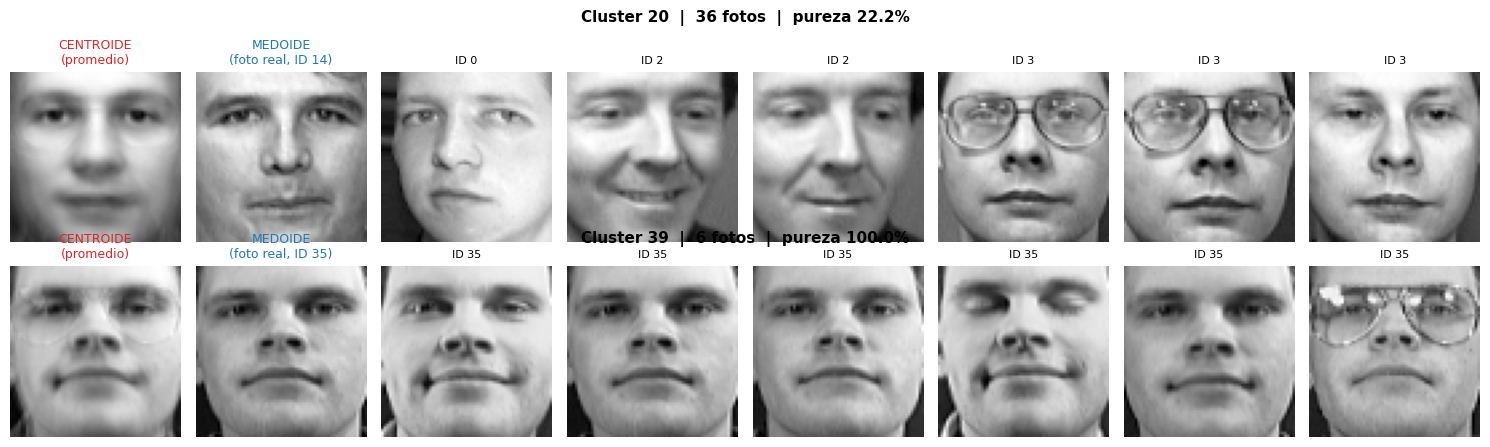

In [24]:
# ==============================================================================
#   CENTROIDE (PROMEDIO BORROSO) vs MEDOIDE (FOTO REAL) EN UN CLUSTER MEZCLADO
# ==============================================================================
# Tomamos el agrupamiento de K-medias sobre el espacio depurado (la mejor configuracion)
resumen_dep = []
for k in range(K_PERSONAS):
    m = labels_dep == k
    if m.sum() > 0:
        conteo = np.bincount(y[m])
        resumen_dep.append({"cluster": k, "n": int(m.sum()),
                            "pureza": np.max(conteo) / m.sum()})
resumen_dep = pd.DataFrame(resumen_dep).sort_values("pureza")

# Un cluster problematico y uno limpio, para contrastar
k_sucio = int(resumen_dep.iloc[0]["cluster"])
k_limpio = int(resumen_dep.iloc[-1]["cluster"])

fig, axes = plt.subplots(2, 8, figsize=(15, 4.6))
for fila, kk in enumerate([k_sucio, k_limpio]):
    idxs = np.where(labels_dep == kk)[0]
    conteo = np.bincount(y[idxs])
    pureza_k = np.max(conteo) / len(idxs)

    # Centroide: promedio de las imagenes del cluster, en espacio de pixeles
    centroide = X[idxs].mean(axis=0)
    # Medoide: la imagen real del cluster mas cercana al centro del grupo
    D_local = pairwise_distances(X[idxs])
    medoide_idx = idxs[np.argmin(D_local.sum(axis=1))]

    axes[fila, 0].imshow(centroide.reshape(64, 64), cmap="gray")
    axes[fila, 0].set_title("CENTROIDE\n(promedio)", fontsize=9, color="tab:red")
    axes[fila, 1].imshow(images[medoide_idx], cmap="gray")
    axes[fila, 1].set_title(f"MEDOIDE\n(foto real, ID {y[medoide_idx]})", fontsize=9, color="tab:blue")

    for col in range(2, 8):
        j = col - 2
        if j < len(idxs):
            axes[fila, col].imshow(images[idxs[j]], cmap="gray")
            axes[fila, col].set_title(f"ID {y[idxs[j]]}", fontsize=8)
    for col in range(8):
        axes[fila, col].axis("off")

    fig.text(0.5, 0.95 - fila * 0.48,
             f"Cluster {kk}  |  {len(idxs)} fotos  |  pureza {pureza_k*100:.1f}%",
             ha="center", fontsize=11, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

**La respuesta operativa se separa de la estadística, y esa es la lección del paso.**

En el cluster limpio el centroide es perfectamente utilizable: promediar diez fotos de la misma persona produce un rostro nítido y reconocible. En el cluster mezclado, en cambio, el centroide promedia caras de personas distintas y el resultado es una máscara difusa que no se parece a nadie. Justo donde el analista más necesita ayuda para detectar el error, el centroide deja de ser informativo.

El medoide no tiene ese problema. **Siempre es una fotografía real**, así que el analista puede compararla directamente contra las demás del grupo y decir "esta no es la misma persona". Un promedio borroso no permite esa comparación.

**Recomendación: usar los dos, cada uno para lo que sirve.** K-medias produce mejores agrupamientos, así que lo usamos para **formar** los grupos. Pero para **mostrarle** cada grupo al analista conviene exhibir el medoide del cluster, es decir la foto real más central, en vez del centroide.

Eso no requiere correr K-medoides. Una vez formados los clusters con K-medias, el medoide de cada uno se calcula directamente como la imagen del grupo con menor distancia total a las demás, que es exactamente lo que hace la celda anterior. Se obtiene la calidad de agrupamiento de K-medias y la interpretabilidad visual de K-medoides.

### Cierre del Paso 5

1. **Implementamos PAM directamente** en lugar de usar `scikit-learn-extra`, que no es instalable en entornos con NumPy 2. El cuaderno queda reproducible sin dependencias frágiles.
2. **La comparación se hizo en igualdad de condiciones**, con las mismas semillas y `n_init=10` en ambos algoritmos. Sin esa corrección, K-medoides aparecía artificialmente peor.
3. **K-medoides no mejora el agrupamiento** en ninguno de los tres espacios, quedando entre 18 y 33 fotos por debajo de K-medias sobre 400.
4. **La causa no es un defecto del algoritmo.** Olivetti no tiene valores atípicos contra los cuales la robustez pague, el medoide está restringido a ser una foto existente, y promediar rostros funciona como filtro de las variaciones de iluminación y expresión.
5. **K-medoides aprovecha solo el 57% de la mejora** que aporta el espacio depurado, 14.5 fotos frente a 25.3 de K-medias. Cuanto mejor es el espacio, más pesa el filtrado que el promedio aporta y que el medoide no puede replicar.
6. **Pero el medoide gana en el uso operativo.** En los clusters mezclados, que son justamente los que requieren revisión humana, el centroide promedia identidades distintas y se vuelve ilegible, mientras que el medoide sigue siendo una foto real comparable.
7. **La configuración recomendada combina ambos**: agrupar con K-medias y presentar el medoide de cada cluster como representante visual para el analista.

# Paso 6. ¿Qué ocurre cuando no conocemos K?

Hasta aquí fijamos $K=40$ porque conocemos las identidades de Olivetti. En el archivo de la empresa esa información es justamente lo que se perdió, así que hay que preguntarse si los criterios habituales para elegir $K$ habrían recuperado ese número.

Barremos $K$ de 5 a 120 sobre el mejor espacio identificado en el Paso 4 y evaluamos con las dos guías del curso, el método del codo y el coeficiente de silueta. Agregamos además dos indicadores que el negocio sí puede interpretar, la proporción de clusters completamente puros y la **fragmentación**, es decir en cuántos grupos distintos terminan repartidas las fotos de una misma persona.

In [25]:
# ==============================================================================
#     BARRIDO DE K SOBRE EL ESPACIO DEPURADO, PROMEDIANDO VARIAS SEMILLAS
# ==============================================================================
# Aplicamos el mismo estandar de los Pasos 4 y 5: una sola semilla no distingue
# señal de ruido de inicializacion. Usamos 5 semillas por cada valor de K.
semillas_K = [123, 0, 7, 42, 2024]
rango_K = list(range(5, 121, 5))

acumulado = {k: {"sil": [], "pur": [], "puros": [], "frag": [], "inercia": []}
             for k in rango_K}

for s in semillas_K:
    for k in rango_K:
        km = KMeans(n_clusters=k, random_state=s, n_init=N_INIT).fit(X_pca_dep)
        lab = km.labels_

        pur_c = [np.max(np.bincount(y[lab == c])) / (lab == c).sum()
                 for c in range(k) if (lab == c).sum() > 0]

        acumulado[k]["sil"].append(silhouette_score(X_pca_dep, lab))
        acumulado[k]["pur"].append(funcion_pureza(y, lab))
        acumulado[k]["puros"].append(np.mean(np.array(pur_c) == 1))
        acumulado[k]["frag"].append(
            np.mean([len(np.unique(lab[y == i])) for i in np.unique(y)]))
        acumulado[k]["inercia"].append(km.inertia_)

barrido_K = pd.DataFrame([{
    "K": k,
    "inercia": np.mean(v["inercia"]),
    "silueta": np.mean(v["sil"]),
    "silueta_sd": np.std(v["sil"]),
    "pureza": np.mean(v["pur"]),
    "pureza_sd": np.std(v["pur"]),
    "pct_clusters_puros": np.mean(v["puros"]),
    "fragmentacion": np.mean(v["frag"]),
} for k, v in acumulado.items()])

barrido_K["caida_inercia_por_unidad_K"] = -barrido_K["inercia"].diff() / 5

print("="*115)
print(f"BARRIDO DE K (media sobre {len(semillas_K)} semillas, n_init={N_INIT})")
print("="*115)
print(barrido_K.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("="*115)

BARRIDO DE K (media sobre 5 semillas, n_init=10)
  K    inercia  silueta  silueta_sd  pureza  pureza_sd  pct_clusters_puros  fragmentacion  caida_inercia_por_unidad_K
  5 14562.2266   0.0560      0.0027  0.1245     0.0010              0.0000         1.8750                         NaN
 10 12971.4568   0.0701      0.0028  0.2455     0.0048              0.1000         1.9800                    318.1539
 15 11875.8479   0.0864      0.0041  0.3410     0.0044              0.1733         2.1000                    219.1218
 20 10977.7967   0.0983      0.0040  0.4340     0.0171              0.2500         2.2150                    179.6102
 25 10119.2732   0.1153      0.0033  0.5135     0.0169              0.3840         2.0450                    171.7047
 30  9409.8365   0.1276      0.0059  0.5950     0.0160              0.4533         2.2200                    141.8873
 35  8731.1664   0.1439      0.0038  0.6690     0.0258              0.4457         2.2800                    135.7340
 40  82

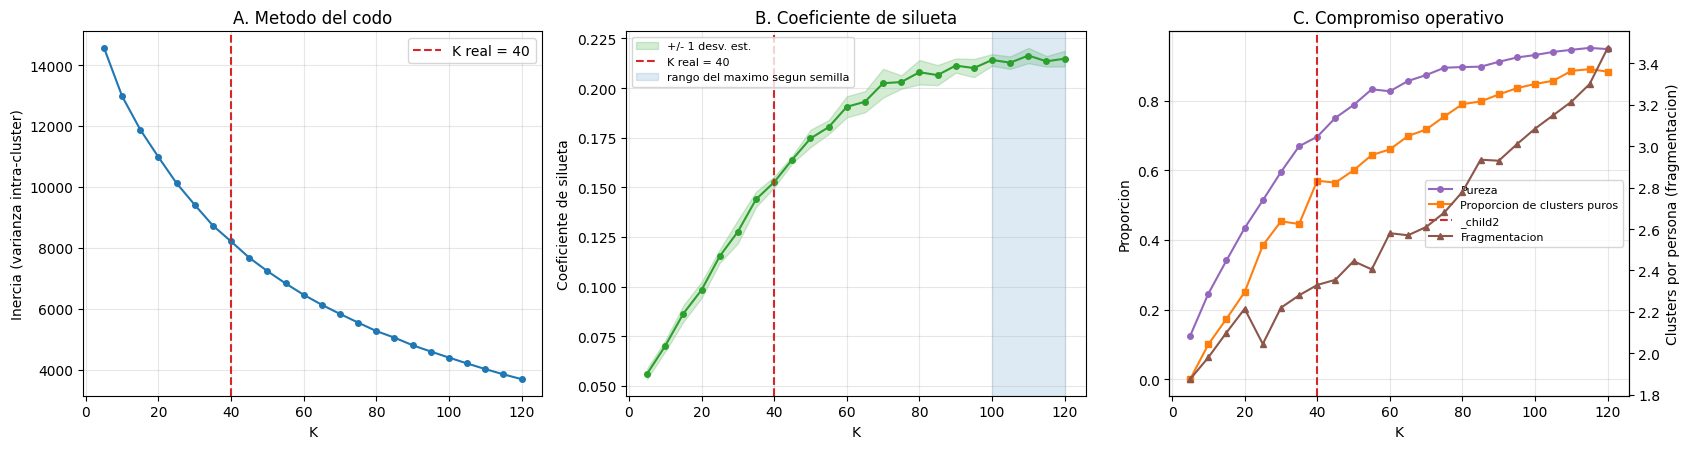

K que maximiza la silueta promedio: 110
Silueta en K=40 (valor real): 0.1526
Silueta maxima: 0.2164

Estabilidad del maximo, K que lo alcanza en cada semilla:
  semilla   123 -> K = 100
  semilla     0 -> K = 100
  semilla     7 -> K = 110
  semilla    42 -> K = 120
  semilla  2024 -> K = 115

Cuatro mejores valores de silueta promedio:
  K  silueta  silueta_sd
110   0.2164      0.0039
120   0.2148      0.0040
100   0.2142      0.0029
115   0.2135      0.0027


In [26]:
# ==============================================================================
#        CODO, SILUETA Y EL COMPROMISO OPERATIVO
# ==============================================================================
k_mejor_silueta = int(barrido_K.loc[barrido_K["silueta"].idxmax(), "K"])

# ¿Que tan estable es ese maximo? Lo recalculamos semilla por semilla.
argmax_por_semilla = {}
for s in semillas_K:
    sils = [silhouette_score(X_pca_dep,
                             KMeans(n_clusters=k, random_state=s,
                                    n_init=N_INIT).fit_predict(X_pca_dep))
            for k in rango_K]
    argmax_por_semilla[s] = rango_K[int(np.argmax(sils))]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

axes[0].plot(barrido_K["K"], barrido_K["inercia"], marker="o", ms=4)
axes[0].axvline(K_PERSONAS, color="tab:red", ls="--", label=f"K real = {K_PERSONAS}")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inercia (varianza intra-cluster)")
axes[0].set_title("A. Metodo del codo")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(barrido_K["K"], barrido_K["silueta"], marker="o", ms=4, color="tab:green")
axes[1].fill_between(barrido_K["K"],
                     barrido_K["silueta"] - barrido_K["silueta_sd"],
                     barrido_K["silueta"] + barrido_K["silueta_sd"],
                     alpha=0.2, color="tab:green", label="+/- 1 desv. est.")
axes[1].axvline(K_PERSONAS, color="tab:red", ls="--", label=f"K real = {K_PERSONAS}")
axes[1].axvspan(min(argmax_por_semilla.values()), max(argmax_por_semilla.values()),
                alpha=0.15, color="tab:blue", label="rango del maximo segun semilla")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Coeficiente de silueta")
axes[1].set_title("B. Coeficiente de silueta")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

ax = axes[2]
ax.plot(barrido_K["K"], barrido_K["pureza"], marker="o", ms=4,
        color="tab:purple", label="Pureza")
ax.plot(barrido_K["K"], barrido_K["pct_clusters_puros"], marker="s", ms=4,
        color="tab:orange", label="Proporcion de clusters puros")
ax.set_xlabel("K"); ax.set_ylabel("Proporcion")
ax.axvline(K_PERSONAS, color="tab:red", ls="--")
ax2 = ax.twinx()
ax2.plot(barrido_K["K"], barrido_K["fragmentacion"], marker="^", ms=4,
         color="tab:brown", label="Fragmentacion")
ax2.set_ylabel("Clusters por persona (fragmentacion)")
lineas = ax.get_lines() + ax2.get_lines()
ax.legend(lineas, [l.get_label() for l in lineas], fontsize=8, loc="center right")
ax.set_title("C. Compromiso operativo")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"K que maximiza la silueta promedio: {k_mejor_silueta}")
print(f"Silueta en K={K_PERSONAS} (valor real): "
      f"{barrido_K.loc[barrido_K.K == K_PERSONAS, 'silueta'].iloc[0]:.4f}")
print(f"Silueta maxima: {barrido_K['silueta'].max():.4f}")
print()
print("Estabilidad del maximo, K que lo alcanza en cada semilla:")
for s, k in argmax_por_semilla.items():
    print(f"  semilla {s:5} -> K = {k}")
print()
print("Cuatro mejores valores de silueta promedio:")
print(barrido_K.nlargest(4, "silueta")[["K", "silueta", "silueta_sd"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

## 6.1 Ninguno de los dos criterios recupera el valor real

**El método del codo no entrega una respuesta.** La curva de inercia desciende de forma continua sin un quiebre nítido. La caída por unidad de $K$ pasa de unos 318 entre $K=5$ y $K=10$ a menos de 40 cerca de $K=120$, pero lo hace de manera gradual. Si alguien insistiera en leer un codo, lo ubicaría alrededor de $K=25$ o $K=30$, donde el ritmo de caída se aplana de unos 175 a unos 140. Eso quedaría **por debajo** del valor real de 40, y la elección sería en buena medida arbitraria.

**La silueta sí da una respuesta, y se equivoca por mucho.** Su máximo promedio está en $K=110$, con 0.2164, frente a 0.1526 en $K=40$. El criterio apunta a **casi tres veces** el número real de personas, y la curva crece con oscilaciones menores desde $K=20$ hasta ese máximo, así que ni siquiera mirando el trazado completo uno se detendría en 40.

**Los dos criterios no coinciden entre sí**, y ninguno coincide con la verdad. En un escenario real, sin etiquetas, habríamos elegido un $K$ equivocado con cualquiera de los dos.

> **Nota metodológica sobre la precisión de este máximo.** Aunque este barrido promedia cinco semillas por cada valor de $K$, el punto exacto donde la silueta alcanza su máximo **no es identificable**. Semilla por semilla el máximo cae en $K=100$, $110$, $115$ o $120$ según el caso, y los cuatro mejores valores promedio difieren entre sí por menos de una desviación estándar.
>
> La inestabilidad va incluso más allá de la semilla. Al repetir la ejecución completa del cuaderno, con las mismas semillas y los mismos parámetros, el $K$ ganador de alguna semilla puede cambiar. La causa es que `KMeans` paraleliza sus iteraciones y eso introduce diferencias numéricas mínimas; con valores de silueta separados por menos de 0.002, eso alcanza para alterar cuál resulta máximo. No es un error de configuración, es una consecuencia directa de que la curva sea prácticamente plana en esa región.
>
> La lectura correcta es que la silueta señala una **zona** aproximada entre 100 y 120, no un óptimo puntual. Lo que sí es robusto a todo ese ruido, y es la conclusión que importa, es que ninguno de los dos criterios recupera $K=40$.

## 6.2 Por qué la pureza tampoco puede usarse para elegir K

Sería tentador usar la pureza como criterio, ya que es la métrica que venimos usando para juzgar calidad. La tabla muestra por qué no sirve para esta decisión: **la pureza crece de forma prácticamente monótona con $K$**, de 0.1245 en $K=5$ a 0.9470 en $K=120$. Sobre la media de cinco semillas solo hay dos retrocesos en veintitrés pasos, ambos menores a 1.5 puntos y dentro de la dispersión entre semillas.

El motivo es aritmético. Cuantos más clusters se permitan, más pequeños son y más fácil es que cada uno contenga una sola identidad. En el extremo, con $K=400$ habría un cluster por fotografía y la pureza sería exactamente 1, con un agrupamiento completamente inútil.

Esto vale también como advertencia para leer el resto del cuaderno: **la pureza sirve para comparar configuraciones con el mismo $K$**, como hicimos en los Pasos 4 y 5, pero no para elegir $K$.

## 6.3 El compromiso que sí le importa al negocio

Los criterios estadísticos no resuelven la elección, pero el problema operativo sí ofrece un criterio propio. Al aumentar $K$ ocurren dos cosas opuestas:

| $K$ | Pureza | Clusters puros | Fragmentación |
|---|---|---|---|
| 40 | 69.7% | 57% | 2.33 |
| 60 | 82.7% | 66% | 2.58 |
| 80 | 89.7% | 79% | 2.78 |
| 100 | 93.1% | 85% | 3.08 |

Con $K$ alto los grupos son más limpios pero las fotos de una misma persona quedan repartidas en más grupos. Con $K$ bajo hay menos dispersión pero los grupos mezclan identidades.

**Los dos errores no le cuestan lo mismo al analista, y esa asimetría decide.**

Un grupo **fragmentado** le presenta al analista dos o tres conjuntos limpios de la misma persona. Reconocer que corresponden al mismo empleado y unirlos es una operación rápida y de bajo riesgo.

Un grupo **mezclado** le presenta un conjunto con varias identidades revueltas. El analista tiene que revisar foto por foto y separarlas, que es más lento y más propenso a error.

Unir es más barato que separar. Por lo tanto, **en este caso de uso conviene pasarse de $K$ antes que quedarse corto**.

Y aquí aparece un resultado irónico que vale la pena nombrar: la silueta señala una zona muy por encima del número real de personas, y esa zona es **operativamente mejor** que el $K=40$ correcto. Con $K=100$ el 85% de los grupos son perfectos y la pureza llega al 93.1%, contra 57% y 69.7% con $K=40$. El precio es que cada empleado aparece en 3.08 grupos en vez de 2.33.

## 6.4 Qué tan desconocido es K en el caso real

Conviene matizar el planteamiento del problema. El enunciado dice que en una aplicación real el número de personas podría no estar disponible, pero en este caso concreto **la empresa sí sabe cuántos empleados tiene**. Recursos Humanos conserva la nómina, lo que se perdió fue la asociación entre cada foto y su dueño, no el listado de personas.

Ese dato es un anclaje valioso, aunque no una respuesta exacta, por tres motivos:

- El archivo puede contener fotos de personas que ya no están en la nómina.
- Puede haber empleados sin fotografía en el archivo.
- Un mismo empleado puede aparecer con fotos de épocas muy distintas, que el algoritmo podría separar legítimamente en grupos diferentes.

Por eso la recomendación operativa no es fijar $K$ igual al número de empleados, sino **partir de ese número y elegir por encima**, coherente con la asimetría de la sección anterior. El número de nómina funciona como piso, no como objetivo.

**La dificultad de fondo permanece.** Sin etiquetas no hay forma de verificar si el $K$ elegido fue el correcto, porque las métricas disponibles o no responden (el codo) o responden mal (la silueta) o son monótonas en $K$ (la pureza). Esto es el mismo problema que enfrentamos al elegir el número de componentes en PCA: es aprendizaje no supervisado, no hay variable respuesta ni validación cruzada contra una verdad conocida.

### Cierre del Paso 6

1. **El método del codo no produce una respuesta utilizable.** La inercia cae de forma continua sin quiebre nítido, y el codo que podría leerse estaría cerca de $K=25$ o $30$, por debajo del valor real.
2. **La silueta señala una zona entre 100 y 120**, casi tres veces el número real de personas. Su máximo promedio está en $K=110$ (0.2164) frente a $K=40$ (0.1526), pero el punto exacto no es identificable: varía con la semilla, los mejores valores no se distinguen entre sí, y hasta repetir la misma corrida puede cambiar cuál gana.
3. **Los dos criterios no coinciden entre sí ni con la verdad.** Sin etiquetas habríamos elegido mal con cualquiera.
4. **La pureza no puede usarse para elegir $K$** porque crece de forma prácticamente monótona: con un cluster por foto sería 1 y el agrupamiento sería inútil.
5. **El criterio operativo sí decide.** Unir grupos fragmentados es más barato que separar grupos mezclados, así que conviene pasarse de $K$ antes que quedarse corto.
6. **La zona de $K$ alto que sugiere la silueta es operativamente mejor que el $K=40$ correcto**: con $K=100$ hay 93.1% de pureza y 85% de grupos perfectos, contra 69.7% y 57%, a cambio de que cada empleado aparezca en 3.08 grupos en vez de 2.33.
7. **En el caso real $K$ no es del todo desconocido**, porque la nómina existe. Sirve como piso para elegir $K$, no como objetivo.
8. **Este barrido promedia cinco semillas por valor de $K$**, siguiendo el mismo estándar de los Pasos 4 y 5. Con una sola semilla las curvas muestran oscilaciones que se confunden fácilmente con estructura real.

# Paso 7. Integración de resultados y recomendación

Reunimos la evidencia de los seis pasos anteriores en un ranking único de configuraciones y traducimos ese resultado en una recomendación para el cliente, con los controles que la empresa tendría que aplicar en producción.

## 7.1 Ranking de configuraciones

In [27]:
# ==============================================================================
#            RANKING CONSOLIDADO DE TODAS LAS CONFIGURACIONES
# ==============================================================================
from sklearn.metrics import silhouette_samples
from scipy.stats import spearmanr

def evaluar_config(nombre_espacio, M, algoritmo, k):
    if algoritmo == "K-medias":
        lab = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT).fit_predict(M)
    else:
        lab = k_medoides(pairwise_distances(M), k,
                         random_state=RANDOM_STATE, n_init=N_INIT)[0]

    purezas_c = []
    for c in np.unique(lab):
        m = lab == c
        purezas_c.append(np.max(np.bincount(y[m])) / m.sum())
    purezas_c = np.array(purezas_c)

    return {
        "espacio": nombre_espacio,
        "algoritmo": algoritmo,
        "K": k,
        "dims": M.shape[1],
        "pureza": funcion_pureza(y, lab),
        "silueta": silhouette_score(M, lab),
        "pct_clusters_puros": (purezas_c == 1).mean(),
        "fragmentacion": np.mean([len(np.unique(lab[y == i])) for i in np.unique(y)]),
    }


espacios_rank = {
    "Pixeles crudos": X,
    f"PCA {n_comp_95} (95%)": Z_full[:, :n_comp_95],
    f"PCA {n_comp_95} sin las 2 primeras": X_pca_dep,
}

filas = []
for nombre, M in espacios_rank.items():
    for alg in ["K-medias", "K-medoides"]:
        filas.append(evaluar_config(nombre, M, alg, K_PERSONAS))

# La configuracion recomendada agrega la decision sobre K
for k in [60, 80, 100]:
    filas.append(evaluar_config(f"PCA {n_comp_95} sin las 2 primeras", X_pca_dep, "K-medias", k))

ranking = pd.DataFrame(filas).sort_values("pureza", ascending=False).reset_index(drop=True)
ranking.insert(0, "puesto", range(1, len(ranking) + 1))

print("="*115)
print("RANKING DE CONFIGURACIONES (semilla 123)")
print("="*115)
print(ranking.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("="*115)

RANKING DE CONFIGURACIONES (semilla 123)
 puesto                    espacio  algoritmo   K  dims  pureza  silueta  pct_clusters_puros  fragmentacion
      1 PCA 123 sin las 2 primeras   K-medias 100   121  0.9325   0.2169              0.8300         3.1000
      2 PCA 123 sin las 2 primeras   K-medias  80   121  0.9125   0.1981              0.8125         2.7250
      3 PCA 123 sin las 2 primeras   K-medias  60   121  0.8425   0.1821              0.6500         2.5250
      4 PCA 123 sin las 2 primeras   K-medias  40   121  0.6875   0.1573              0.6250         2.2500
      5             Pixeles crudos   K-medias  40  4096  0.6750   0.1492              0.4250         2.5000
      6              PCA 123 (95%)   K-medias  40   123  0.6450   0.1726              0.4000         2.7500
      7              PCA 123 (95%) K-medoides  40   123  0.5850   0.1420              0.4000         3.1750
      8 PCA 123 sin las 2 primeras K-medoides  40   121  0.5675   0.1101              0.4750   

**Cómo leer este ranking, y qué no dice.**

La tabla ordena por pureza, pero **la pureza no es comparable entre filas con distinto $K$**, por lo demostrado en la sección 6.2: crece de forma mecánica al aumentar el número de clusters. Las tres últimas filas, con $K$ de 60, 80 y 100, aparecen arriba en parte por esa razón y no solo por ser mejores.

La comparación válida se hace en dos ejes separados.

**A $K$ fijo en 40, comparando espacios y algoritmos**, el orden es claro y ya lo establecimos con diez semillas en los Pasos 4 y 5: K-medias sobre PCA descartando los dos primeros componentes es la mejor combinación, seguida de PCA al 95%, y K-medoides queda por debajo de K-medias en los tres espacios.

**A espacio y algoritmo fijos, comparando $K$**, el Paso 6 mostró que subir $K$ mejora la pureza y la proporción de grupos limpios, a costa de fragmentar más. Es una decisión operativa, no estadística.

## 7.2 ¿Es viable el clustering para reconciliar el archivo?

**Sí, pero no como sistema automático. Sirve como herramienta de preclasificación con revisión humana obligatoria.**

La evidencia sostiene las dos mitades de esa afirmación.

**A favor de que sirve.** En la mejor configuración a $K=40$ la pureza media es del 70%, y subiendo $K$ a 100 llega al 93.3% con el 83% de los grupos perfectamente puros. Eso significa que el algoritmo hace la mayor parte del trabajo pesado: en vez de que un analista revise 400 fotos sin ninguna estructura, recibe un centenar de grupos donde la mayoría ya está bien formada.

**En contra de automatizarlo.** Ni siquiera en el mejor escenario el resultado es confiable sin supervisión. Con $K=100$ queda un 17% de grupos con mezcla de identidades, y un archivo de recursos humanos no admite asignar la foto equivocada a un expediente. Además, todas las cifras anteriores provienen de un entorno mucho más controlado que el archivo real.

La pregunta operativa entonces no es si automatizar o no, sino **cuánto del archivo puede aprobarse sin mirar y cuánto exige revisión**. Eso requiere un criterio que funcione sin etiquetas, que es lo que construimos a continuación.

## 7.3 Un criterio de triage que funciona sin etiquetas

Todo lo que medimos hasta aquí usó las identidades reales, que en el archivo de la empresa **no existen**. Si el analista no puede saber qué grupos están limpios, el sistema no sirve de mucho.

Buscamos entonces señales calculables sin etiquetas que predigan la pureza de un grupo. Probamos tres: la silueta media del cluster, su compacidad y su tamaño.

In [28]:
# ==============================================================================
#   ¿QUE SEÑALES SIN ETIQUETAS PREDICEN LA PUREZA DE UN CLUSTER?
# ==============================================================================
def diagnostico_clusters(M, k):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT).fit(M)
    lab = km.labels_
    sil = silhouette_samples(M, lab)

    filas = []
    for c in range(k):
        m = lab == c
        if m.sum() == 0:
            continue
        filas.append({
            "cluster": c,
            "n_fotos": int(m.sum()),
            "silueta_media": sil[m].mean(),
            "compacidad": np.linalg.norm(M[m] - km.cluster_centers_[c], axis=1).mean(),
            "pureza_real": np.max(np.bincount(y[m])) / m.sum(),  # solo para validar
        })
    return pd.DataFrame(filas), lab


for k in [K_PERSONAS, 100]:
    diag, _ = diagnostico_clusters(X_pca_dep, k)
    print("="*80)
    print(f"K = {k}   ({len(diag)} clusters)")
    print("="*80)
    print("Correlacion de Spearman con la pureza real:")
    print(f"  silueta media del cluster : {spearmanr(diag.silueta_media, diag.pureza_real).statistic:+.3f}")
    print(f"  compacidad                : {spearmanr(diag.compacidad, diag.pureza_real).statistic:+.3f}")
    print(f"  tamano del cluster        : {spearmanr(diag.n_fotos, diag.pureza_real).statistic:+.3f}")
    print()

K = 40   (40 clusters)
Correlacion de Spearman con la pureza real:
  silueta media del cluster : +0.705
  compacidad                : -0.537
  tamano del cluster        : -0.822



K = 100   (100 clusters)
Correlacion de Spearman con la pureza real:
  silueta media del cluster : +0.436
  compacidad                : -0.427
  tamano del cluster        : -0.424



**Las tres señales funcionan, y una es sorprendentemente fuerte.**

Con $K=40$, el **tamaño del cluster** correlaciona con la pureza en -0.822. Es la señal más potente de las tres y también la más fácil de explicar al cliente: si sabemos que cada empleado tiene aproximadamente diez fotos, un grupo de veinticinco **necesariamente** contiene más de una persona. No hace falta estadística para justificarlo, es aritmética.

La **silueta media del cluster** correlaciona +0.705 con $K=40$ y +0.436 con $K=100$, y tiene la ventaja de que no depende de conocer cuántas fotos hay por empleado.

Con esas señales podemos construir una regla de triage: aprobar automáticamente los grupos que superen cierto umbral de silueta y enviar el resto a revisión humana. Medimos qué tan bien funciona.

In [29]:
# ==============================================================================
#        PROTOCOLO DE TRIAGE: ¿CUANTO SE PUEDE APROBAR SIN MIRAR?
# ==============================================================================
K_RECOMENDADO = 100
diag100, lab100 = diagnostico_clusters(X_pca_dep, K_RECOMENDADO)

filas = []
for umbral in [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]:
    auto = diag100[diag100.silueta_media >= umbral]
    if len(auto) == 0:
        continue
    fotos = int(auto.n_fotos.sum())
    filas.append({
        "umbral_silueta": umbral,
        "clusters_auto": len(auto),
        "fotos_auto": fotos,
        "pct_archivo_auto": fotos / len(y),
        "pct_grupos_perfectos": (auto.pureza_real == 1).mean(),
        "pureza_ponderada": (auto.pureza_real * auto.n_fotos).sum() / fotos,
        "fotos_a_revision": int(len(y) - fotos),
    })

triage = pd.DataFrame(filas)
print("="*105)
print(f"PROTOCOLO DE TRIAGE CON K={K_RECOMENDADO} SOBRE EL ESPACIO DEPURADO")
print("="*105)
print(triage.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("="*105)

PROTOCOLO DE TRIAGE CON K=100 SOBRE EL ESPACIO DEPURADO
 umbral_silueta  clusters_auto  fotos_auto  pct_archivo_auto  pct_grupos_perfectos  pureza_ponderada  fotos_a_revision
         0.0000             98         396            0.9900                0.8367            0.9343                 4
         0.0500             81         345            0.8625                0.8765            0.9594                55
         0.1000             77         321            0.8025                0.9091            0.9720                79
         0.1500             66         263            0.6575                0.9545            0.9810               137
         0.2000             53         208            0.5200                0.9811            0.9952               192
         0.2500             42         151            0.3775                1.0000            1.0000               249


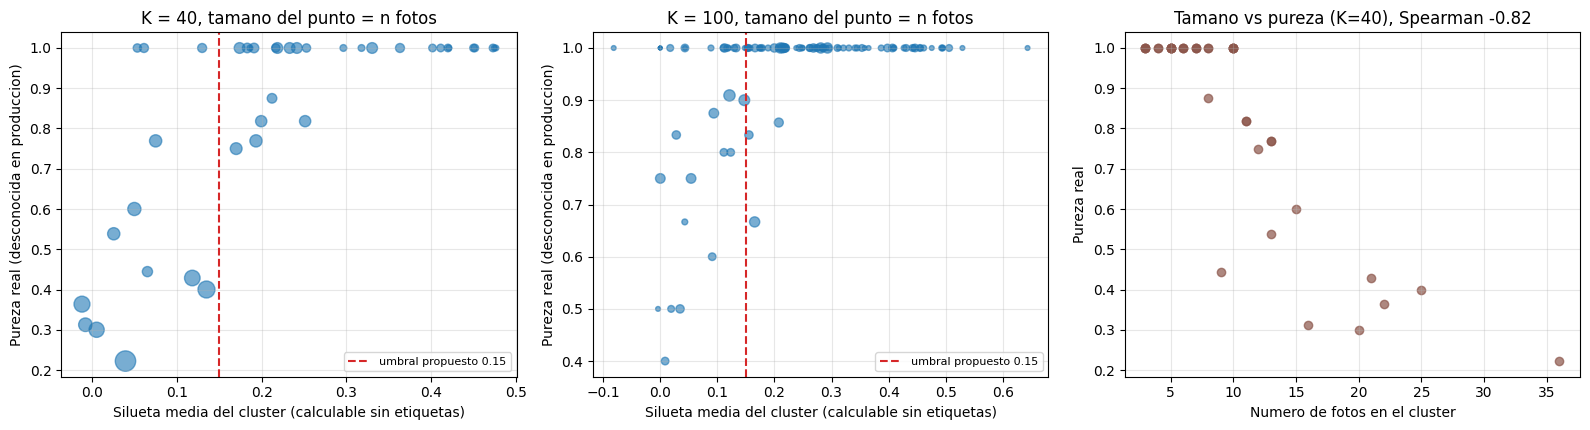

In [30]:
# ==============================================================================
#     VISUALIZACION: LAS SEÑALES SIN ETIQUETAS CONTRA LA PUREZA REAL
# ==============================================================================
diag40, _ = diagnostico_clusters(X_pca_dep, K_PERSONAS)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

for ax, (d, k) in zip(axes[:2], [(diag40, K_PERSONAS), (diag100, K_RECOMENDADO)]):
    ax.scatter(d.silueta_media, d.pureza_real, s=d.n_fotos * 6, alpha=0.6)
    ax.axvline(0.15, color="tab:red", ls="--", label="umbral propuesto 0.15")
    ax.set_xlabel("Silueta media del cluster (calculable sin etiquetas)")
    ax.set_ylabel("Pureza real (desconocida en produccion)")
    ax.set_title(f"K = {k}, tamano del punto = n fotos")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

axes[2].scatter(diag40.n_fotos, diag40.pureza_real, alpha=0.7, color="tab:brown")
axes[2].set_xlabel("Numero de fotos en el cluster")
axes[2].set_ylabel("Pureza real")
axes[2].set_title(f"Tamano vs pureza (K={K_PERSONAS}), Spearman -0.82")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**El protocolo recomendado, con cifras.**

Con $K=100$ sobre el espacio depurado y un umbral de silueta media de **0.15**:

- Se aprueban automáticamente **66 grupos, que cubren 263 fotos, el 66% del archivo**.
- De esos grupos, el **95% son perfectamente puros**, y la pureza ponderada del lote aprobado es **98.1%**.
- Las **137 fotos restantes, el 34%**, van a revisión humana.

Comparado con revisar 400 fotos sin ninguna estructura, el analista revisa 137 y recibe además los otros grupos ya formados para confirmar. Y el umbral es una perilla ajustable: subirlo a 0.20 deja el lote automático en 208 fotos con 99.5% de pureza, bajarlo a 0.10 aprueba 321 fotos con 97.2%.

**La empresa elige dónde poner el umbral según cuánto error tolere**, y esa es exactamente la decisión que debe tomar el cliente, no nosotros.

## 7.4 Del lote controlado al archivo real

Todas las cifras anteriores provienen de Olivetti, y **la traslación al archivo de la empresa no es directa**. Cuatro diferencias importan.

**Olivetti es un entorno mucho más benigno.** Fondo uniforme, encuadre constante, escala idéntica, resolución homogénea y fotos tomadas en una misma sesión. El archivo real tendrá cámaras distintas, décadas distintas, encuadres variables y calidad desigual. Es razonable esperar que todas las métricas se degraden.

**El envejecimiento no está representado.** Las diez fotos de una persona en Olivetti son contemporáneas entre sí. En un archivo de recursos humanos con años de historia, dos fotos del mismo empleado pueden diferir más entre sí que las fotos de dos personas distintas de edad similar. Este es probablemente el riesgo más subestimado.

**La escala cambia el problema.** Olivetti tiene 400 fotos y 40 personas. El archivo tiene unas 10.000 fotos. Eso multiplica por 25 el volumen y hace que $K$ sea mucho mayor, con un costo computacional que crece y, sobre todo, con muchísimas más oportunidades de coincidencia espuria entre personas parecidas.

**Y una advertencia sobre nuestra propia metodología.** La configuración que recomendamos, descartar los dos primeros componentes, **la encontramos mirando las etiquetas reales**. En el archivo de la empresa esas etiquetas no existen, así que no habría forma de repetir esa optimización ni de verificar que el número elegido de componentes sea el adecuado. Lo mismo vale para el umbral de triage de 0.15: lo calibramos contra la pureza conocida.

Esto no invalida la recomendación, pero define con precisión qué hay que hacer antes de confiar en ella.

## 7.5 Qué evaluar antes de aplicarlo al archivo completo

En este orden, porque cada paso condiciona al siguiente.

1. **Etiquetar manualmente una muestra del archivo real**, de unas 300 a 500 fotos con identidad confirmada. Sin esa muestra no hay forma de calibrar nada ni de saber cuánto se degradan las métricas fuera de Olivetti. Es el paso que no se puede saltar.
2. **Repetir sobre esa muestra las decisiones de preprocesamiento**, en particular cuántos componentes descartar y si conviene estandarizar. La sección 2.2.1 mostró que en Olivetti estandarizar es indiferente porque no hay fondo constante, pero si las fotos de carné conservan fondo uniforme esa conclusión podría invertirse.
3. **Recalibrar el umbral de triage** contra la muestra etiquetada, y fijar con el cliente la pureza mínima aceptable del lote automático antes de medirla. Acordar ese número de antemano evita que cualquier resultado se narre como éxito.
4. **Medir el impacto del envejecimiento** comparando fotos del mismo empleado tomadas con varios años de diferencia, que es la variable ausente en Olivetti.
5. **Definir la tasa de auditoría muestral permanente.** Aun con el lote automático aprobado, conviene revisar al azar una fracción de él de forma continua, para detectar degradación con el tiempo o con nuevas cámaras.

**La decisión concreta que se solicita al cliente** es aprobar una prueba piloto sobre una muestra etiquetada del archivo real, no el despliegue sobre las 10.000 fotos. El presupuesto principal de esa fase no es de cómputo sino del trabajo humano de etiquetar la muestra de calibración.

### Cierre del Paso 7

1. **El clustering es viable como preclasificación, no como automatización.** Reduce drásticamente el trabajo del analista pero no elimina la revisión humana.
2. **La configuración recomendada es K-medias sobre PCA descartando los dos primeros componentes**, que fue la mejor con diez semillas y rangos que no se solapan con el espacio crudo.
3. **Con $K=100$**, por encima de las 40 personas reales, porque unir grupos fragmentados le cuesta menos al analista que separar grupos mezclados. Elegimos el extremo inferior de la zona que señala la silueta (100 a 120) para limitar la fragmentación.
4. **El triage se hace con la silueta media de cada cluster**, que correlaciona con la pureza sin necesitar etiquetas. Con umbral 0.15 se aprueba el 66% del archivo con 98.1% de pureza y se envía el 34% a revisión.
5. **El tamaño del cluster es la señal más simple y más fuerte** con $K=40$ (Spearman -0.82), y se explica sin estadística: un grupo mucho mayor que las fotos esperadas por empleado necesariamente mezcla identidades.
6. **Las cifras no se trasladan directamente al archivo real**, que tiene cámaras, épocas y encuadres heterogéneos, más el envejecimiento que Olivetti no representa.
7. **Antes de escalar hace falta una muestra etiquetada del archivo real.** Es el requisito que habilita todo lo demás, y el principal costo de la siguiente fase es humano, no computacional.